# Preditor de Resultados UFC — Pipeline Completo de Machine Learning

**Disciplina:** Linguagem de Programação Python Aplicada a Machine Learning  
**Versão:** v5 (2026)

---

## Etapa 1 — Definindo o Problema

### O que estamos tentando resolver?

O UFC (Ultimate Fighting Championship) é a maior organização de MMA (artes marciais mistas) do mundo.
Todo evento tem lutas com dois lutadores e, no final, só um ganha.

**Nossa missão:** construir um modelo de Machine Learning capaz de prever **qual dos dois lutadores vai vencer** — antes da luta acontecer.

Tecnicamente, isso é um problema de **classificação binária** (dois resultados possíveis):

| Valor do target | Significado |
|---|---|
| **1** | Fighter_1 vence |
| **0** | Fighter_2 vence |

### Por que isso é útil?

- Análise de apostas esportivas e mercados de predição
- Preparação tática de equipes — entender as vantagens do adversário
- Analytics esportivo e inteligência competitiva

### De onde vêm os dados?
https://www.kaggle.com/datasets/jossilva3110/ufc-dataset-1994-2026
- **8.551 lutas** registradas (ufcstats.com, de 1994 até 2026)
- **4.455 lutadores** com estatísticas de carreira completas
- As features (variáveis de entrada) incluem:
  - **Físicas:** altura, peso, alcance (wingspan)
  - **Técnicas:** golpes por minuto (SLpM), precisão, takedowns
  - **Históricas:** taxa de vitórias (Win Rate), total de lutas

### Nossa hipótese

> A diferença nas estatísticas de carreira entre dois lutadores é um bom preditor do resultado.
> Lutadores com vantagem consistente em striking, grappling e experiência tendem a vencer mais.

Em outras palavras: os números da carreira dizem bastante sobre quem é melhor — e o modelo vai aprender esses padrões.


## Etapa 2 — Preparação e Limpeza dos Dados

Antes de qualquer coisa, precisamos deixar os dados limpos e organizados.
Dados crus raramente chegam perfeitos — vêm com valores faltando, formatos esquisitos e inconsistências.

Nesta etapa vamos:
1. Carregar os arquivos CSV com os dados de lutadores e lutas
2. Converter unidades (pés/polegadas para centímetros, percentuais para decimais)
3. Preencher valores ausentes com a mediana de cada coluna
4. Lidar com valores extremos (outliers) usando Winsorização


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, 
)
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost disponivel!")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[AVISO] XGBoost nao instalado. Execute: pip install xgboost")

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
SEED = 42
print('Bibliotecas carregadas com sucesso!')


XGBoost disponivel!
Bibliotecas carregadas com sucesso!


In [2]:
fighters = pd.read_csv('DATA/ufc_fighters_final.csv')
fights   = pd.read_csv('DATA/ufc_gold_dataset_final.csv')
print(f'Lutadores: {fighters.shape[0]:,} x {fighters.shape[1]}')
print(f'Lutas:     {fights.shape[0]:,} x {fights.shape[1]}')
print(f'Periodo:   {fights["Event_Date"].min()} a {fights["Event_Date"].max()}')
print()
print('Colunas — Lutadores:', list(fighters.columns))
print('Colunas — Lutas:    ', list(fights.columns))


Lutadores: 4,455 x 18
Lutas:     8,551 x 37
Periodo:   1994-03-11 a 2026-03-07

Colunas — Lutadores: ['Fighter_Name', 'Height', 'Weight', 'Reach', 'Stance', 'DOB', 'Wins', 'Losses', 'Draws', 'SLpM', 'Str_Acc', 'SApM', 'Str_Def', 'TD_Avg', 'TD_Acc', 'TD_Def', 'Sub_Avg', 'Fighter_URL']
Colunas — Lutas:     ['Fight_URL', 'Fighter_1', 'Fighter_2', 'Winner', 'Weight_Class', 'Method', 'End_Round', 'End_Time', 'Total_Fight_Time_Sec', 'Time_Format', 'F1_KD', 'F2_KD', 'F1_Sig_Landed', 'F1_Sig_Att', 'F2_Sig_Landed', 'F2_Sig_Att', 'F1_TD_Landed', 'F2_TD_Landed', 'F1_TD_Att', 'F2_TD_Att', 'F1_Sub_Att', 'F2_Sub_Att', 'F1_Ctrl_Sec', 'F2_Ctrl_Sec', 'F1_Head', 'F2_Head', 'F1_Body', 'F2_Body', 'F1_Leg', 'F2_Leg', 'F1_Distance', 'F2_Distance', 'F1_Clinch', 'F2_Clinch', 'F1_Ground', 'F2_Ground', 'Event_Date']


In [3]:
print("=== Dataset de Lutas ===")
print(f"Metodos de vitoria:\n{fights['Method'].value_counts()}")
print(f"\nTop 10 categorias de peso:\n{fights['Weight_Class'].value_counts().head(10)}")
print(f"\nValores nulos — Lutas:\n{fights.isnull().sum().sort_values(ascending=False).head(5)}")
print("\n=== Dataset de Lutadores ===")
print(f"Valores nulos — Lutadores:\n{fighters.isnull().sum().sort_values(ascending=False).head(6)}")


=== Dataset de Lutas ===
Metodos de vitoria:
Method
Decision - Unanimous       3083
KO/TKO                     2688
Submission                 1655
Decision - Split            815
Decision - Majority          98
TKO - Doctor's Stoppage      97
Overturned                   58
Could Not Continue           32
DQ                           23
Other                         2
Name: count, dtype: int64

Top 10 categorias de peso:
Weight_Class
Lightweight Bout            1376
Welterweight Bout           1318
Middleweight Bout           1075
Featherweight Bout           809
Bantamweight Bout            733
Heavyweight Bout             698
Light Heavyweight Bout       686
Flyweight Bout               379
Women's Strawweight Bout     337
Women's Flyweight Bout       254
Name: count, dtype: int64

Valores nulos — Lutas:
Fight_URL       0
Fighter_1       0
Fighter_2       0
Winner          0
Weight_Class    0
dtype: int64

=== Dataset de Lutadores ===
Valores nulos — Lutadores:
Reach           1940


### 2.1 Conversão de Unidades — Limpando os Dados dos Lutadores

O site do UFC armazena altura no famoso formato americano (`5'11"`) e alcance em polegadas.
Precisamos converter tudo para centímetros e formatos numéricos que o Python entenda.

As funções abaixo fazem esse trabalho:
- `parse_height()` → converte `5'11"` para `180.3 cm`
- `parse_weight()` → extrai o número de `"170 lbs."`
- `parse_reach()` → converte `72.0"` para `182.9 cm`
- `parse_pct()` → converte `"64%"` para `0.64` (decimal)

Também calculamos duas colunas novas:
- **Win_Rate** = Vitórias ÷ Total de lutas (proporção de vitórias na carreira)
- **Age** = Idade estimada com base na data de nascimento


In [4]:
def parse_height(h):
    """Converte altura no formato 5'11\" para centimetros."""
    if pd.isna(h) or str(h).strip() == '': return np.nan
    m = re.match(r"(\d+)'\s*(\d+)\"", str(h))
    return round((int(m.group(1))*12 + int(m.group(2)))*2.54, 1) if m else np.nan

def parse_weight(w):
    """Extrai o valor numerico do peso em libras."""
    if pd.isna(w) or str(w).strip() == '': return np.nan
    m = re.search(r'([\d.]+)', str(w))
    return float(m.group(1)) if m else np.nan

def parse_reach(r):
    """Converte alcance de polegadas para centimetros."""
    if pd.isna(r) or str(r).strip() == '': return np.nan
    m = re.search(r'([\d.]+)', str(r))
    return round(float(m.group(1))*2.54, 1) if m else np.nan

def parse_pct(p):
    """Converte percentual (ex: '64%') para decimal (0.64)."""
    if pd.isna(p) or str(p).strip() == '': return np.nan
    m = re.search(r'([\d.]+)', str(p))
    return float(m.group(1))/100 if m else np.nan

fighters['Height_cm']  = fighters['Height'].apply(parse_height)
fighters['Weight_lbs'] = fighters['Weight'].apply(parse_weight)
fighters['Reach_cm']   = fighters['Reach'].apply(parse_reach)
fighters['Str_Acc_f']  = fighters['Str_Acc'].apply(parse_pct)
fighters['Str_Def_f']  = fighters['Str_Def'].apply(parse_pct)
fighters['TD_Acc_f']   = fighters['TD_Acc'].apply(parse_pct)
fighters['TD_Def_f']   = fighters['TD_Def'].apply(parse_pct)

total = fighters['Wins'] + fighters['Losses'] + fighters['Draws']
fighters['Win_Rate']     = np.where(total > 0, fighters['Wins']/total, np.nan)
fighters['Total_Fights'] = total
fighters['DOB'] = pd.to_datetime(fighters['DOB'], errors='coerce')
fighters['Age'] = ((pd.Timestamp('2024-01-01') - fighters['DOB']).dt.days / 365.25).round(1)

print('Conversoes aplicadas com sucesso!')
print(f"  Height_cm  — validos: {fighters['Height_cm'].notna().sum():,}")
print(f"  Reach_cm   — validos: {fighters['Reach_cm'].notna().sum():,}")
print(f"  Age        — validos: {fighters['Age'].notna().sum():,}")
print(f"  Win_Rate   — validos: {fighters['Win_Rate'].notna().sum():,}")


Conversoes aplicadas com sucesso!
  Height_cm  — validos: 4,137
  Reach_cm   — validos: 2,515
  Age        — validos: 3,949
  Win_Rate   — validos: 4,436


### 2.2 Preenchendo Dados Faltantes e Controlando Outliers

Dois problemas muito comuns em dados reais:

**1. Valores ausentes (NaN — Not a Number):**  
Muitos lutadores não têm dados de alcance ou data de nascimento cadastrados.
A solução mais simples e eficaz é preencher com a **mediana** da coluna.
A mediana é mais robusta do que a média quando há valores extremos.

**2. Outliers (valores fora do comum):**  
Alguns lutadores têm estatísticas muito fora do padrão que podem confundir o modelo.
Usamos **Winsorização**: limitamos os valores entre o percentil 1% e 99%.
Isso não remove os dados — apenas "apara" os extremos, como cortar as pontas de uma distribuição.

> **Por que mediana e não média?**  
> Se a maioria pesa 170 lbs mas um atleta pesa 300, a mediana ainda fica em ~170, enquanto a média sobe injustamente. A mediana é resistente a outliers.


In [5]:
FIGHTER_FEATURES = [
    'Height_cm', 'Weight_lbs', 'Reach_cm', 'Age',
    'Win_Rate', 'Total_Fights',
    'SLpM', 'Str_Acc_f', 'SApM', 'Str_Def_f',
    'TD_Avg', 'TD_Acc_f', 'TD_Def_f', 'Sub_Avg'
]

fighters_clean = fighters[['Fighter_Name'] + FIGHTER_FEATURES].copy()

# PASSO 1: Imputar nulos pela mediana ANTES de calcular outliers
for col in FIGHTER_FEATURES:
    med = fighters_clean[col].median()
    fighters_clean[col] = fighters_clean[col].fillna(med)

print("=== Analise de Outliers (IQR) — pos-imputacao ===")
outlier_report = []
for col in FIGHTER_FEATURES:
    Q1  = fighters_clean[col].quantile(0.25)
    Q3  = fighters_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((fighters_clean[col] < lb) | (fighters_clean[col] > ub)).sum()
    pct   = 100 * n_out / len(fighters_clean)
    outlier_report.append({'Feature': col, 'Outliers IQR': n_out, 'Percentual': f'{pct:.1f}%',
                            'Lower Bound': round(lb,3), 'Upper Bound': round(ub,3)})
    print(f"  {col:<20}  outliers: {n_out:>4} ({pct:.1f}%)  limites: [{lb:.2f}, {ub:.2f}]")

print()
df_outlier = pd.DataFrame(outlier_report)
print(df_outlier.to_string(index=False))

# PASSO 2: Winsorization — clip nos percentis 1% e 99%
# Razao: outliers extremos (ex: lutador com 0 lutas, stats zeradas) distorcem
# features diferenciais sem representar informacao util para o modelo.
# A Winsorization preserva os registros mas limita valores extremos.
for col in FIGHTER_FEATURES:
    p01 = fighters_clean[col].quantile(0.01)
    p99 = fighters_clean[col].quantile(0.99)
    fighters_clean[col] = fighters_clean[col].clip(lower=p01, upper=p99)

print(f'\nWinsorization aplicada (percentis 1%-99%) para todas as {len(FIGHTER_FEATURES)} features.')
print(f'Lutadores no dataset limpo: {len(fighters_clean):,}')
print(f'Nulos restantes: {fighters_clean[FIGHTER_FEATURES].isnull().sum().sum()}')


=== Analise de Outliers (IQR) — pos-imputacao ===
  Height_cm             outliers:   56 (1.3%)  limites: [157.40, 198.20]
  Weight_lbs            outliers:  250 (5.6%)  limites: [85.00, 245.00]
  Reach_cm              outliers: 1617 (36.3%)  limites: [176.40, 186.80]
  Age                   outliers:   74 (1.7%)  limites: [17.12, 57.73]
  Win_Rate              outliers:  238 (5.3%)  limites: [0.33, 1.04]
  Total_Fights          outliers:  161 (3.6%)  limites: [-11.00, 45.00]
  SLpM                  outliers:   50 (1.1%)  limites: [-3.29, 7.88]
  Str_Acc_f             outliers:   30 (0.7%)  limites: [-0.03, 0.80]
  SApM                  outliers:  165 (3.7%)  limites: [-2.31, 8.27]
  Str_Def_f             outliers:  756 (17.0%)  limites: [0.05, 0.88]
  TD_Avg                outliers:  183 (4.1%)  limites: [-2.91, 4.85]
  TD_Acc_f              outliers:    0 (0.0%)  limites: [-0.66, 1.10]
  TD_Def_f              outliers:    0 (0.0%)  limites: [-1.01, 1.68]
  Sub_Avg               outli

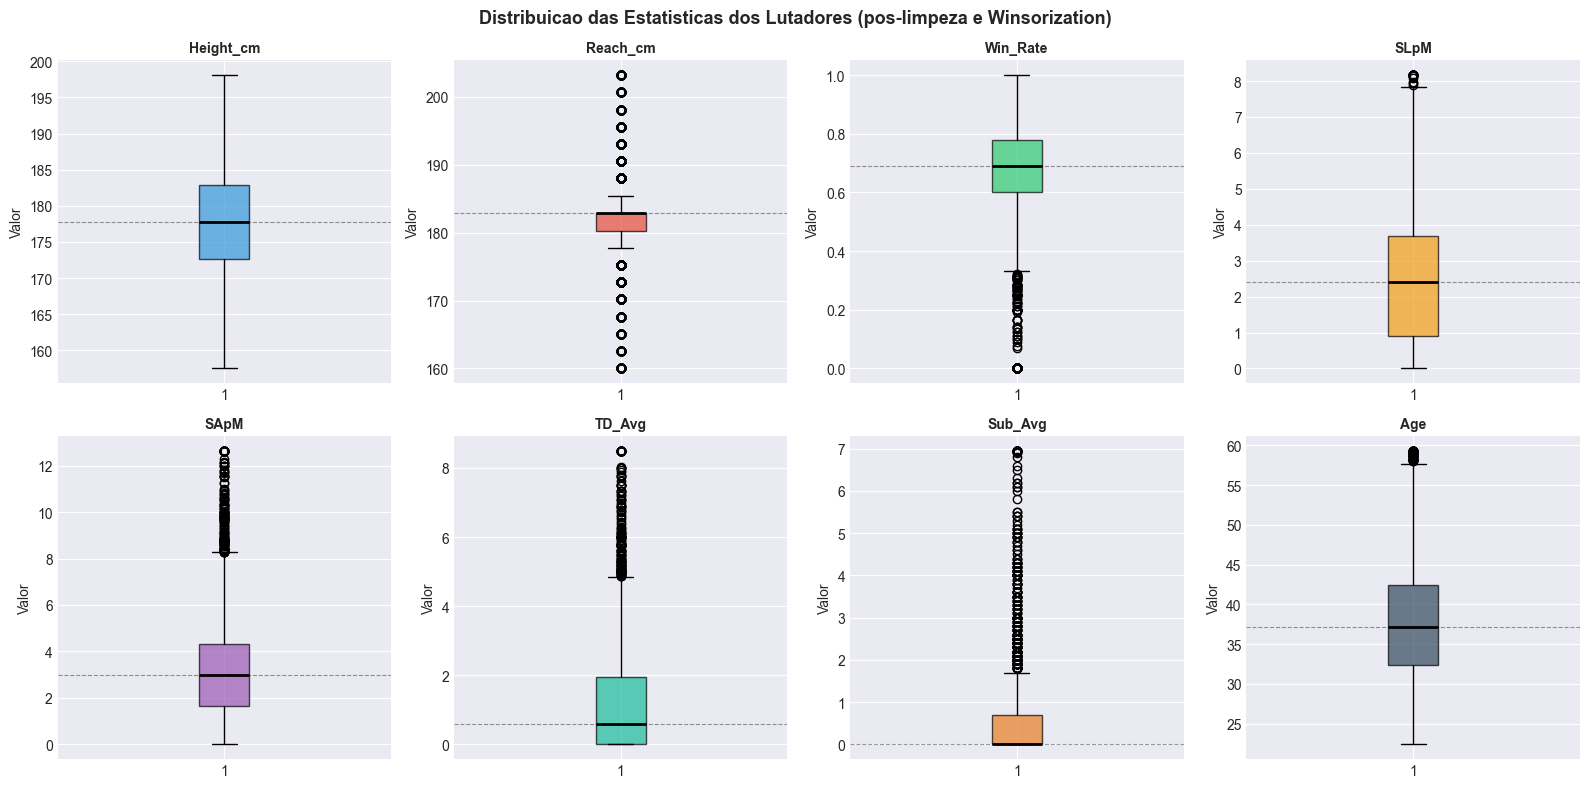

Boxplots gerados. Outliers residuais apos Winsorization sao minimos.


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribuicao das Estatisticas dos Lutadores (pos-limpeza e Winsorization)',
             fontsize=13, fontweight='bold')

cols_plot = ['Height_cm', 'Reach_cm', 'Win_Rate', 'SLpM', 'SApM', 'TD_Avg', 'Sub_Avg', 'Age']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

for ax, col, color in zip(axes.flat, cols_plot, colors):
    ax.boxplot(fighters_clean[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Valor')
    med = fighters_clean[col].median()
    ax.axhline(med, color='black', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()
print('Boxplots gerados. Outliers residuais apos Winsorization sao minimos.')


### 2.3 Preparando o Dataset de Lutas — Criando o Target

Aqui definimos exatamente o que queremos prever: **quem ganhou**.

Passos realizados:
1. **Remover lutas sem resultado definido** (empates, sem-decisão, "no contests")
2. **Criar a coluna `target`**: vale **1** se Fighter_1 ganhou, **0** se Fighter_2 ganhou
3. **Codificar numericamente as categorias de peso** — algoritmos de ML precisam de números, não texto

Também verificamos o **balanceamento das classes**:
Se houvesse muito mais vitórias de F1 do que F2, o modelo poderia aprender a chutar sempre a mesma resposta e ainda assim ter boa acurácia. Felizmente, nosso dataset está bem balanceado!


In [7]:
fights_clean = fights.dropna(subset=['Fighter_1', 'Fighter_2', 'Winner']).copy()

# Manter apenas lutas com resultado definido (sem empates ou NC)
mask_valid = (
    (fights_clean['Winner'] == fights_clean['Fighter_1']) |
    (fights_clean['Winner'] == fights_clean['Fighter_2'])
)
fights_clean = fights_clean[mask_valid].copy()
fights_clean['target'] = (fights_clean['Winner'] == fights_clean['Fighter_1']).astype(int)

# Encoding da categoria de peso
def extract_weight_class(wc):
    """Extrai a categoria base da string de categoria de peso."""
    categories = [
        'Strawweight', 'Flyweight', 'Bantamweight', 'Featherweight',
        'Lightweight', 'Welterweight', 'Middleweight', 'Light Heavyweight',
        'Heavyweight', 'Super Heavyweight', "Women's"
    ]
    for cat in categories:
        if cat in str(wc):
            return cat
    return 'Other'

fights_clean['Weight_Class_Cat'] = fights_clean['Weight_Class'].apply(extract_weight_class)
wc_le = LabelEncoder()
fights_clean['Weight_Class_Enc'] = wc_le.fit_transform(fights_clean['Weight_Class_Cat'])

print(f'Lutas com resultado definido: {fights_clean.shape[0]:,}')
print(f'Balanceamento: {fights_clean["target"].mean():.1%} Fighter_1 vence')
print(f'\nCategorias de peso codificadas:')
for label, code in zip(wc_le.classes_, range(len(wc_le.classes_))):
    n = (fights_clean['Weight_Class_Cat'] == label).sum()
    print(f'  {code:>2}: {label:<25}  ({n:,} lutas)')


Lutas com resultado definido: 8,400
Balanceamento: 64.2% Fighter_1 vence

Categorias de peso codificadas:
   0: Bantamweight               (985 lutas)
   1: Featherweight              (857 lutas)
   2: Flyweight                  (669 lutas)
   3: Heavyweight                (744 lutas)
   4: Light Heavyweight          (728 lutas)
   5: Lightweight                (1,405 lutas)
   6: Middleweight               (1,113 lutas)
   7: Other                      (177 lutas)
   8: Strawweight                (357 lutas)
   9: Welterweight               (1,365 lutas)


### 2.4 Análise Exploratória dos Dados 

Antes de treinar qualquer modelo, é essencial entender os dados visualmente.
Para ajuda a enxergar padrões, anomalias e insights que os números brutos escondem.

Vamos explorar:
1. **Balanceamento do target** — quantas vitórias de F1 vs F2?
2. **Métodos de vitória** — nocaute, finalização ou decisão dos juízes?
3. **Categorias de peso** — em qual divisão acontecem mais lutas?
4. **Evolução temporal** — como o UFC cresceu desde 1994?
5. **Correlação entre estatísticas** — quais features andam juntas?
6. **Métodos de vitória por período** — o MMA mudou ao longo do tempo?
7. **Striking por nível de desempenho** — lutadores melhores batem mais e levam menos?


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np

In [9]:
COLOR_RED   = "#d65f5f"
COLOR_GREEN = "#4daf7c"
COLOR_BLUE  = "#4c78a8"
COLOR_ORANGE = "#f28e2b"
COLOR_PURPLE = "#9c6ade"
COLOR_GRAY = "#6b7280"

In [ ]:
# ── 2.4 Análise Exploratória dos Dados (EDA) ─────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

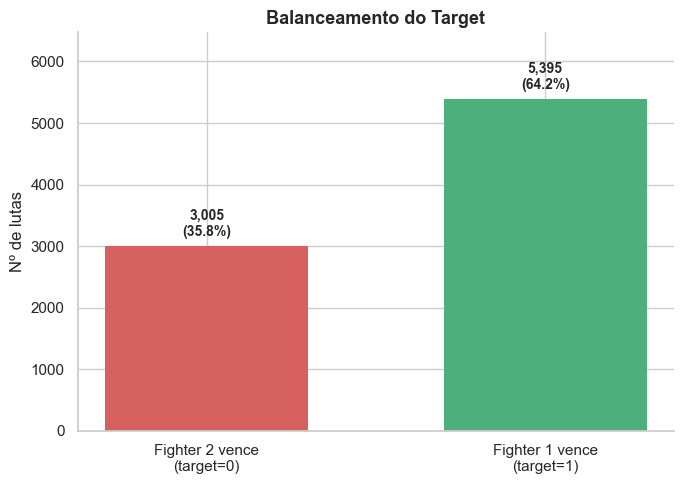

In [ ]:


sns.set_theme(style="whitegrid", context="notebook")

# ── 1. Balanceamento do Target ────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 5), facecolor="white")

target_counts = fights_clean["target"].value_counts().sort_index()
labels_target = ["Fighter 2 vence\n(target=0)", "Fighter 1 vence\n(target=1)"]
bars = ax1.bar(
    labels_target,
    target_counts.values,
    color=[COLOR_RED, COLOR_GREEN],
    edgecolor="none",
    width=0.6
)

for bar, val in zip(bars, target_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + target_counts.max() * 0.02,
        f"{val:,}\n({val/len(fights_clean):.1%})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax1.set_title("Balanceamento do Target", fontsize=13, fontweight="bold")
ax1.set_ylabel("Nº de lutas")
ax1.set_ylim(0, target_counts.max() * 1.20)
ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

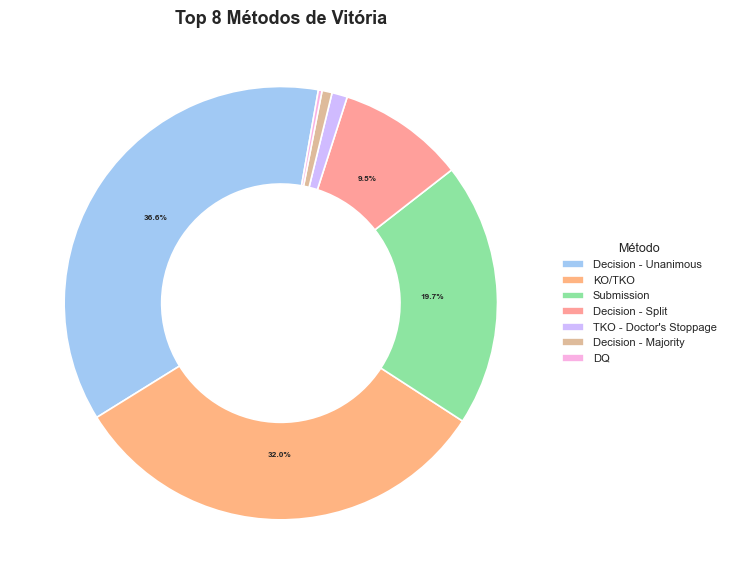

In [11]:
# ── 2. Distribuição por Método de Vitória ────────────────────────────────────
fig, ax2 = plt.subplots(figsize=(8, 6), facecolor="white")

method_counts = fights_clean["Method"].value_counts().head(8)

colors_method = sns.color_palette("pastel", len(method_counts))
wedges, texts, autotexts = ax2.pie(
    method_counts.values,
    autopct=lambda p: f"{p:.1f}%" if p >= 4 else "",
    startangle=80,
    colors=colors_method,
    pctdistance=0.70,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.2)
)

for at in autotexts:
    at.set_fontsize(6)
    at.set_fontweight("bold")

ax2.legend(
    wedges,
    method_counts.index,
    title="Método",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=8,
    title_fontsize=9,
    frameon=False
)
ax2.set_title("Top 8 Métodos de Vitória", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

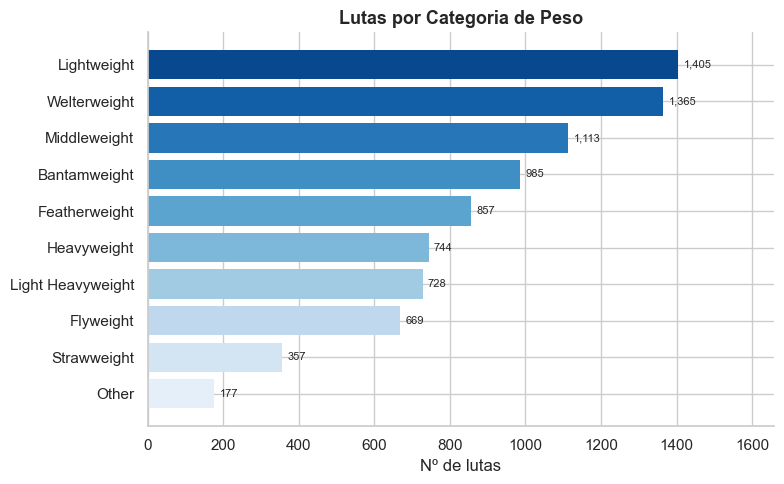

In [12]:
# ── 3. Lutas por Categoria de Peso ───────────────────────────────────────────
fig, ax3 = plt.subplots(figsize=(8, 5), facecolor="white")

wc_counts = fights_clean["Weight_Class_Cat"].value_counts().sort_values()

bars_h = ax3.barh(
    wc_counts.index,
    wc_counts.values,
    color=sns.color_palette("Blues", len(wc_counts)),
    edgecolor="none"
)

for bar, val in zip(bars_h, wc_counts.values):
    ax3.text(
        val + wc_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=8
    )

ax3.set_title("Lutas por Categoria de Peso", fontsize=13, fontweight="bold")
ax3.set_xlabel("Nº de lutas")
ax3.set_xlim(0, wc_counts.max() * 1.18)
ax3.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

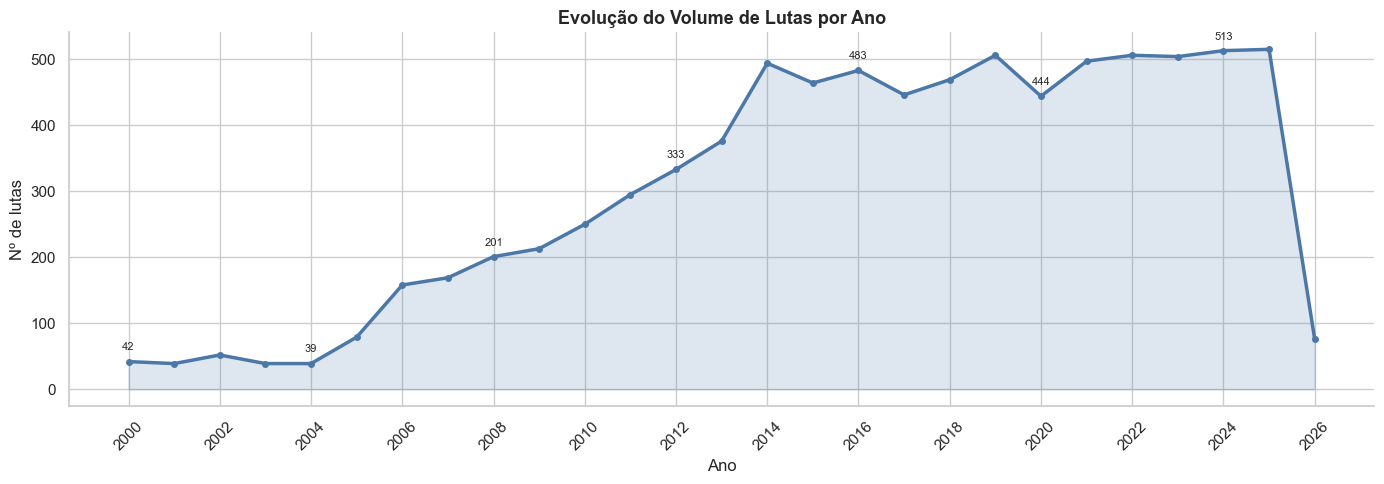

In [13]:
# ── 4. Evolução Temporal das Lutas ───────────────────────────────────────────
fig, ax4 = plt.subplots(figsize=(14, 5), facecolor="white")

fights_ts = fights_clean.copy()
fights_ts["Event_Date_dt"] = pd.to_datetime(fights_ts["Event_Date"], errors="coerce")
fights_ts["Ano"] = fights_ts["Event_Date_dt"].dt.year

timeline = fights_ts.groupby("Ano").size().reset_index(name="count")
timeline = timeline[timeline["Ano"] >= 2000]

ax4.fill_between(timeline["Ano"], timeline["count"], alpha=0.18, color=COLOR_BLUE)
ax4.plot(
    timeline["Ano"],
    timeline["count"],
    color=COLOR_BLUE,
    linewidth=2.5,
    marker="o",
    markersize=4
)

for _, row in timeline.iterrows():
    if int(row["Ano"]) % 4 == 0:
        ax4.annotate(
            f'{int(row["count"])}',
            (row["Ano"], row["count"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8
        )

ax4.set_title("Evolução do Volume de Lutas por Ano", fontsize=13, fontweight="bold")
ax4.set_xlabel("Ano")
ax4.set_ylabel("Nº de lutas")
ax4.set_xticks(timeline["Ano"][::2])
ax4.tick_params(axis="x", rotation=45)
ax4.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

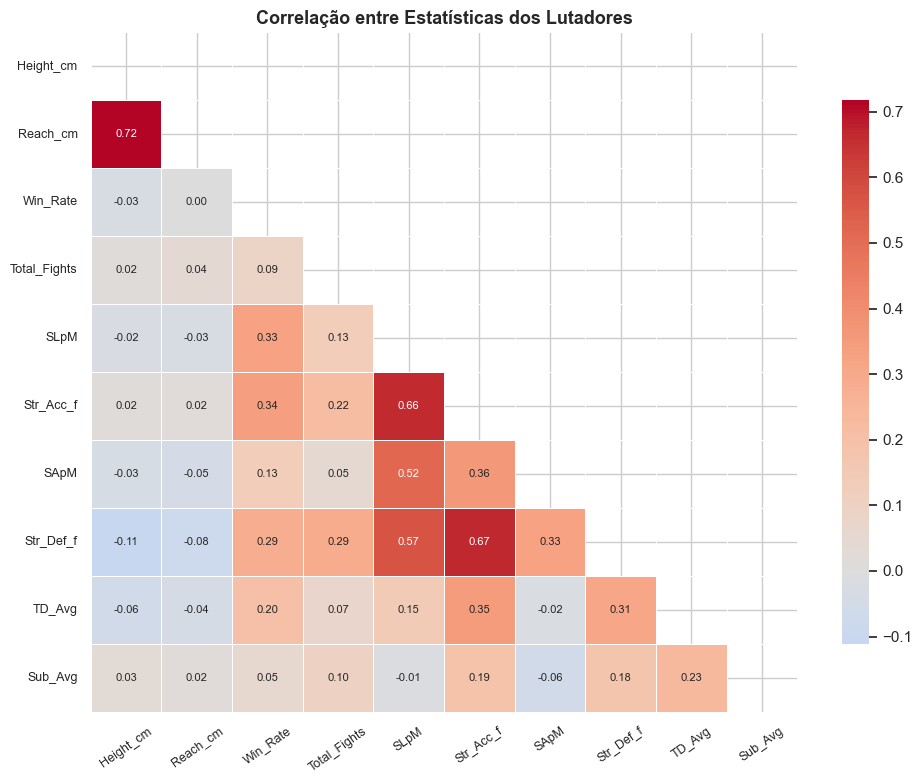

In [14]:
# ── 5. Correlação entre Estatísticas dos Lutadores ───────────────────────────
fig, ax5 = plt.subplots(figsize=(10, 8), facecolor="white")

corr_feats = [
    "Height_cm", "Reach_cm", "Win_Rate", "Total_Fights",
    "SLpM", "Str_Acc_f", "SApM", "Str_Def_f", "TD_Avg", "Sub_Avg"
]

corr_matrix = fighters_clean[corr_feats].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax5,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

ax5.set_title("Correlação entre Estatísticas dos Lutadores", fontsize=13, fontweight="bold")
ax5.tick_params(axis="x", rotation=35, labelsize=9)
ax5.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

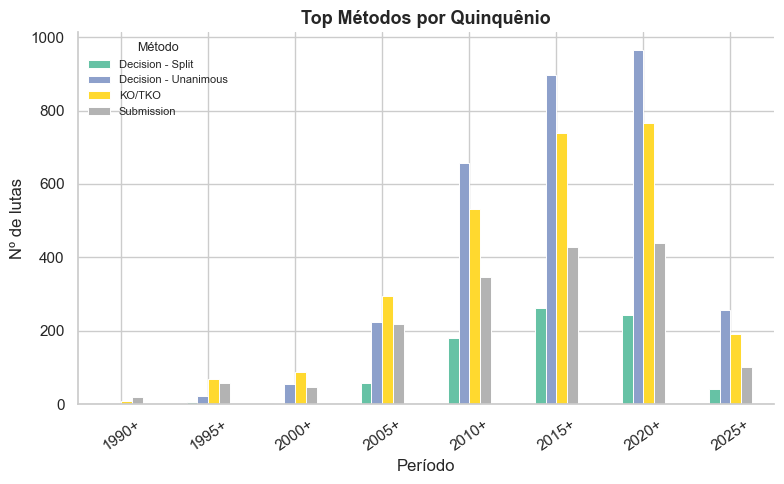

In [15]:
# ── 6. Top Métodos de Vitória por Quinquênio ─────────────────────────────────
fig, ax6 = plt.subplots(figsize=(8, 5), facecolor="white")

fights_ts["Quinquenio"] = (
    (fights_ts["Event_Date_dt"].dt.year // 5 * 5).astype("Int64").astype(str) + "+"
)

top_methods = fights_clean["Method"].value_counts().head(4).index

dec_method = (
    fights_ts[fights_ts["Method"].isin(top_methods)]
    .groupby(["Quinquenio", "Method"])
    .size()
    .reset_index(name="count")
)

dec_method = dec_method[dec_method["Quinquenio"].str.match(r"^\d")]
pivot_dec = dec_method.pivot(index="Quinquenio", columns="Method", values="count").fillna(0)

pivot_dec.plot(
    kind="bar",
    ax=ax6,
    colormap="Set2",
    edgecolor="white",
    linewidth=0.7
)

ax6.set_title("Top Métodos por Quinquênio", fontsize=13, fontweight="bold")
ax6.set_xlabel("Período")
ax6.set_ylabel("Nº de lutas")
ax6.tick_params(axis="x", rotation=35)
ax6.legend(title="Método", fontsize=8, title_fontsize=9, frameon=False)
ax6.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

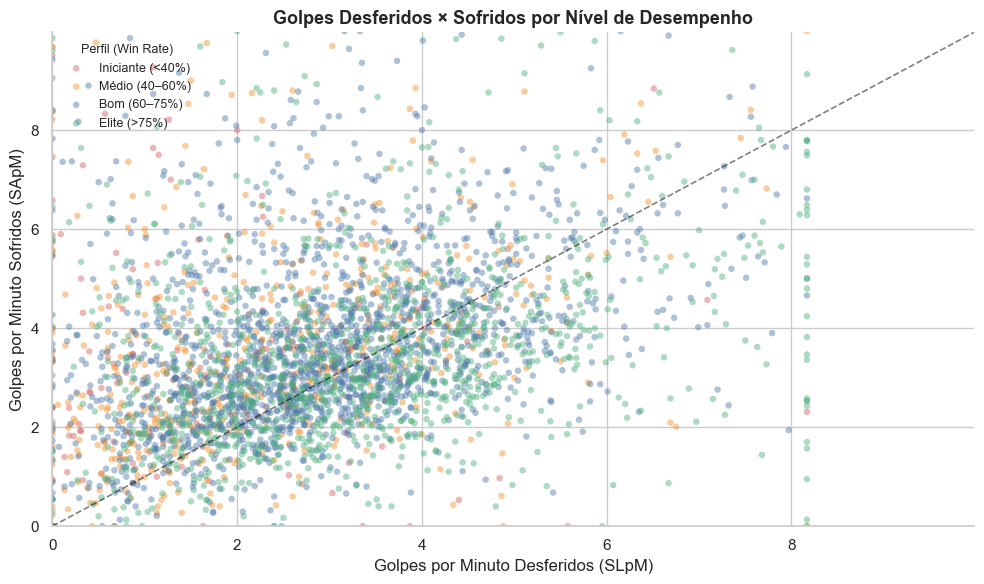

In [16]:
# ── 7. Scatter: Golpes Desferidos × Sofridos por Nível de Desempenho ────────
fig, ax7 = plt.subplots(figsize=(10, 6), facecolor="white")

fighters_plot = fighters_clean.copy()
fighters_plot["Perfil"] = pd.cut(
    fighters_plot["Win_Rate"],
    bins=[0, 0.40, 0.60, 0.75, 1.01],
    labels=["Iniciante (<40%)", "Médio (40–60%)", "Bom (60–75%)", "Elite (>75%)"]
)

paleta = {
    "Iniciante (<40%)": COLOR_RED,
    "Médio (40–60%)": COLOR_ORANGE,
    "Bom (60–75%)": COLOR_BLUE,
    "Elite (>75%)": COLOR_GREEN
}

for label, grp in fighters_plot.groupby("Perfil", observed=True):
    ax7.scatter(
        grp["SLpM"],
        grp["SApM"],
        label=str(label),
        alpha=0.45,
        s=22,
        color=paleta.get(str(label), COLOR_GRAY),
        edgecolors="none"
    )

lim_max = max(
    fighters_plot["SLpM"].quantile(0.98),
    fighters_plot["SApM"].quantile(0.98)
)

ax7.plot([0, lim_max], [0, lim_max], linestyle="--", linewidth=1.2, color="black", alpha=0.5)
ax7.set_xlim(0, lim_max)
ax7.set_ylim(0, lim_max)
ax7.set_xlabel("Golpes por Minuto Desferidos (SLpM)")
ax7.set_ylabel("Golpes por Minuto Sofridos (SApM)")
ax7.set_title("Golpes Desferidos × Sofridos por Nível de Desempenho", fontsize=13, fontweight="bold")
ax7.legend(title="Perfil (Win Rate)", fontsize=9, title_fontsize=9, frameon=False, loc="upper left")
ax7.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
# ── Resumo Estatístico Textual ───────────────────────────────────────────────
print("=" * 65)
print("RESUMO ESTATÍSTICO — EDA")
print("=" * 65)
print(f"Total de lutas válidas : {len(fights_clean):,}")
print(f"Total de lutadores     : {len(fighters_clean):,}")

periodo_dt = pd.to_datetime(fights_clean["Event_Date"], errors="coerce")
print(f"Período coberto        : {int(periodo_dt.dt.year.min())} – {int(periodo_dt.dt.year.max())}")
print(f"Balanceamento target   : {fights_clean['target'].mean():.1%} Fighter 1 vence")
print()

print("Top-5 métodos de vitória:")
for m, c in fights_clean["Method"].value_counts().head(5).items():
    print(f"  {m:<30} {c:>5,} ({c/len(fights_clean):.1%})")

print()
print("Estatísticas descritivas (lutadores):")
print(
    fighters_clean[["Win_Rate", "SLpM", "SApM", "TD_Avg", "Sub_Avg", "Reach_cm"]]
    .describe()
    .round(2)
    .to_string()
)

RESUMO ESTATÍSTICO — EDA
Total de lutas válidas : 8,400
Total de lutadores     : 4,455
Período coberto        : 1994 – 2026
Balanceamento target   : 64.2% Fighter 1 vence

Top-5 métodos de vitória:
  Decision - Unanimous           3,076 (36.6%)
  KO/TKO                         2,688 (32.0%)
  Submission                     1,655 (19.7%)
  Decision - Split                 798 (9.5%)
  TKO - Doctor's Stoppage           97 (1.2%)

Estatísticas descritivas (lutadores):
       Win_Rate     SLpM     SApM   TD_Avg  Sub_Avg  Reach_cm
count   4455.00  4455.00  4455.00  4455.00  4455.00   4455.00
mean       0.67     2.48     3.16     1.21     0.53    182.26
std        0.19     1.89     2.41     1.64     1.07      7.92
min        0.00     0.00     0.00     0.00     0.00    160.00
25%        0.60     0.90     1.66     0.00     0.00    180.30
50%        0.69     2.41     2.99     0.60     0.00    182.90
75%        0.78     3.69     4.30     1.94     0.70    182.90
max        1.00     8.17    12.62 

## Etapa 3 — Engenharia de Features (Criando as Variáveis para o Modelo)

### A ideia central: features diferenciais

Em vez de passar as estatísticas de cada lutador separadamente, criamos **diferenças** entre eles:

```
DIFF_SLpM = SLpM do Fighter_1 - SLpM do Fighter_2
```

Por que isso funciona bem?
- Se o valor for **positivo** → Fighter_1 tem vantagem nessa estatística
- Se for **negativo** → Fighter_2 tem vantagem
- O modelo aprende a associar vantagens consistentes com vitórias
- Garante **invariância posicional** (o resultado não deve depender de quem é chamado F1 ou F2)

### Features compostas — indo além das diferenças simples

Além das diferenças brutas, criamos variáveis que **combinam** estatísticas:

| Feature | Fórmula (simplificada) | O que mede |
|---|---|---|
| DIFF_Efficiency | SLpM × Acc - SApM × (1-Def) | Eficiência líquida no striking |
| DIFF_TD_Success | TD_Avg × TD_Acc | Takedowns bem-sucedidos por minuto |
| DIFF_Grappling_Ctrl | TD_Avg × TD_Def + Sub_Avg | Controle geral do grappling |
| DIFF_Strike_Ratio | SLpM / (SApM + ε) | Golpes desferidos vs sofridos |
| DIFF_Weighted_Exp | Win_Rate × log(Total_Fights + 1) | Experiência ponderada pela qualidade |
| DIFF_Streak | Sequência de vitórias F1 - F2 | Momento atual ("quem está em alta") |

### Data Augmentation por simetria posicional

Uma técnica inteligente: para cada luta `F1 vs F2`, criamos uma cópia espelhada `F2 vs F1`.
Isso dobra o tamanho do dataset e garante que o modelo aprenda que o resultado depende de **quem é melhor**, não de quem foi chamado de F1.

Resultado: dataset vai de ~8.500 para ~17.000 linhas, com target 50/50 perfeitamente balanceado.


In [18]:
def compute_streak(fights_df, fighter_col, result_col='target', date_col='Event_Date'):
    """
    Calcula a sequencia de vitorias de cada lutador antes de cada luta.

    A streak e calculada de forma TEMPORAL: para cada luta, conta quantas
    vitorias consecutivas o lutador teve nas lutas ANTERIORES (sem data leakage).

    Parametros:
    -----------
    fights_df   : DataFrame com as lutas
    fighter_col : 'Fighter_1' ou 'Fighter_2'
    result_col  : coluna com resultado (1 = Fighter_1 vence, 0 = Fighter_2 vence)
    date_col    : coluna de data do evento

    Retorna:
    --------
    Series com a streak de vitorias para cada linha do DataFrame.
    """
    df_temp = fights_df[[fighter_col, result_col, date_col]].copy()
    df_temp[date_col] = pd.to_datetime(df_temp[date_col], errors='coerce')
    df_temp = df_temp.sort_values(date_col).reset_index(drop=True)

    # Para Fighter_1: win = (target == 1); para Fighter_2: win = (target == 0)
    if fighter_col == 'Fighter_1':
        df_temp['won'] = (df_temp[result_col] == 1).astype(int)
    else:
        df_temp['won'] = (df_temp[result_col] == 0).astype(int)

    streak_map = {}   # fighter_name -> current streak
    streaks = []

    for idx, row in df_temp.iterrows():
        fighter = row[fighter_col]
        # Streak ANTES desta luta
        current_streak = streak_map.get(fighter, 0)
        streaks.append(current_streak)
        # Atualizar streak com o resultado desta luta
        if row['won'] == 1:
            streak_map[fighter] = current_streak + 1
        else:
            streak_map[fighter] = 0

    return pd.Series(streaks, index=df_temp.index)

# Ordenar por data antes de calcular streaks
fights_clean['Event_Date'] = pd.to_datetime(fights_clean['Event_Date'], errors='coerce')
fights_clean = fights_clean.sort_values('Event_Date').reset_index(drop=True)

fights_clean['streak_F1'] = compute_streak(fights_clean, 'Fighter_1')
fights_clean['streak_F2'] = compute_streak(fights_clean, 'Fighter_2')

print('Streaks calculadas (sem data leakage).')
print(f'  Streak media F1: {fights_clean["streak_F1"].mean():.2f}')
print(f'  Streak media F2: {fights_clean["streak_F2"].mean():.2f}')
print(f'  Max streak F1:   {fights_clean["streak_F1"].max()}')
print(f'  Max streak F2:   {fights_clean["streak_F2"].max()}')


Streaks calculadas (sem data leakage).
  Streak media F1: 1.47
  Streak media F2: 0.49
  Max streak F1:   19
  Max streak F2:   9


In [19]:
fighters_idx = fighters_clean.set_index('Fighter_Name')

streak_cols = [c for c in ['streak_F1', 'streak_F2'] if c in fights_clean.columns]
base_cols   = ['Fighter_1', 'Fighter_2', 'target', 'Weight_Class_Enc', 'Method'] + streak_cols

df = fights_clean[base_cols].copy()
df = df.merge(fighters_idx.add_prefix('F1_'), left_on='Fighter_1', right_index=True, how='inner')
df = df.merge(fighters_idx.add_prefix('F2_'), left_on='Fighter_2', right_index=True, how='inner')

print(f'Lutas com stats de ambos os lutadores: {df.shape[0]:,}')
print(f'Colunas no df mesclado: {df.shape[1]}')
print(f'\nAmostra das colunas F1:')
print([c for c in df.columns if c.startswith('F1_')])


Lutas com stats de ambos os lutadores: 8,445
Colunas no df mesclado: 35

Amostra das colunas F1:
['F1_Height_cm', 'F1_Weight_lbs', 'F1_Reach_cm', 'F1_Age', 'F1_Win_Rate', 'F1_Total_Fights', 'F1_SLpM', 'F1_Str_Acc_f', 'F1_SApM', 'F1_Str_Def_f', 'F1_TD_Avg', 'F1_TD_Acc_f', 'F1_TD_Def_f', 'F1_Sub_Avg']


In [ ]:
# ── Features diferenciais basicas ─────────────────────────────
DIFF_FEATURES = []
for feat in FIGHTER_FEATURES:
    col_name = f'DIFF_{feat}'
    df[col_name] = df[f'F1_{feat}'] - df[f'F2_{feat}']
    DIFF_FEATURES.append(col_name)

# ── Features compostas (dominio) ────────────────
# Eficiencia liquida de trocação: ataque util - dano recebido
df['DIFF_Efficiency'] = (
    (df['F1_SLpM'] * df['F1_Str_Acc_f'] - df['F1_SApM'] * (1 - df['F1_Str_Def_f'])) -
    (df['F2_SLpM'] * df['F2_Str_Acc_f'] - df['F2_SApM'] * (1 - df['F2_Str_Def_f']))
)

# Volume de derrubar para o chao bem-sucedidos por minuto
df['DIFF_TD_Success'] = (
    (df['F1_TD_Avg'] * df['F1_TD_Acc_f']) -
    (df['F2_TD_Avg'] * df['F2_TD_Acc_f'])
)

# Controle geral do controle do chao (defesa de TD + submissoes)
df['DIFF_Grappling_Ctrl'] = (
    (df['F1_TD_Def_f'] * 0.5 + df['F1_Sub_Avg'] * 0.5) -
    (df['F2_TD_Def_f'] * 0.5 + df['F2_Sub_Avg'] * 0.5)
)

# Razao ataque/defesa no trocação
df['DIFF_Strike_Ratio'] = (
    (df['F1_SLpM'] / (df['F1_SApM'] + 0.001)) -
    (df['F2_SLpM'] / (df['F2_SApM'] + 0.001))
)

# Experiencia ponderada pela taxa de vitoria
df['DIFF_Weighted_Exp'] = (
    (df['F1_Win_Rate'] * np.log1p(df['F1_Total_Fights'])) -
    (df['F2_Win_Rate'] * np.log1p(df['F2_Total_Fights']))
)

# Momentum recente (diferenca de streaks)
df['DIFF_Streak'] = df['streak_F1'] - df['streak_F2']

ENGINEERED_FEATURES = [
    'DIFF_Efficiency', 'DIFF_TD_Success', 'DIFF_Grappling_Ctrl',
    'DIFF_Strike_Ratio', 'DIFF_Weighted_Exp', 'DIFF_Streak'
]

# Weight_Class_Enc: categoria de peso como feature global da luta
ALL_FEATURES = DIFF_FEATURES + ENGINEERED_FEATURES + ['Weight_Class_Enc']

print(f'Features diferenciais basicas: {len(DIFF_FEATURES)}')
print(f'Features compostas:            {len(ENGINEERED_FEATURES)}')
print(f'Features de contexto (peso):   1 (Weight_Class_Enc)')
print(f'Total ALL_FEATURES:            {len(ALL_FEATURES)}')
print(f'\nTodas as features:')
for i, f in enumerate(ALL_FEATURES, 1):
    print(f'  {i:>2}. {f}')


Features diferenciais basicas: 14
Features compostas:            6
Features de contexto (peso):   1 (Weight_Class_Enc)
Total ALL_FEATURES:            21

Todas as features:
   1. DIFF_Height_cm
   2. DIFF_Weight_lbs
   3. DIFF_Reach_cm
   4. DIFF_Age
   5. DIFF_Win_Rate
   6. DIFF_Total_Fights
   7. DIFF_SLpM
   8. DIFF_Str_Acc_f
   9. DIFF_SApM
  10. DIFF_Str_Def_f
  11. DIFF_TD_Avg
  12. DIFF_TD_Acc_f
  13. DIFF_TD_Def_f
  14. DIFF_Sub_Avg
  15. DIFF_Efficiency
  16. DIFF_TD_Success
  17. DIFF_Grappling_Ctrl
  18. DIFF_Strike_Ratio
  19. DIFF_Weighted_Exp
  20. DIFF_Streak
  21. Weight_Class_Enc


In [21]:
# Augmentacao por simetria posicional:
# Se F1 vs F2 com resultado 1 (F1 vence), entao
# F2 vs F1 com resultado 0 (F1 perde) e logicamente equivalente.
# Isso duplica os dados E balanceia o target em 50/50.

df_swap = df.copy()
df_swap['target'] = 1 - df_swap['target']

# Negar apenas features DIFERENCIAIS (F1 - F2 vira F2 - F1 = -(F1-F2))
# Weight_Class_Enc NAO e negado (e o mesmo para ambos os lutadores)
cols_to_negate = DIFF_FEATURES + ENGINEERED_FEATURES
for col in cols_to_negate:
    if col in df_swap.columns:
        df_swap[col] = -df_swap[col]

df_aug = (
    pd.concat([df, df_swap], ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f'Lutas originais:  {len(df):,}')
print(f'Lutas aumentadas: {len(df_aug):,}  (x2 por simetria posicional)')
print(f'Balanceamento:    {df_aug["target"].mean():.1%} Fighter_1 vence (esperado: 50.0%)')
print(f'\nNulos em ALL_FEATURES: {df_aug[ALL_FEATURES].isnull().sum().sum()}')


Lutas originais:  8,445
Lutas aumentadas: 16,890  (x2 por simetria posicional)
Balanceamento:    50.0% Fighter_1 vence (esperado: 50.0%)

Nulos em ALL_FEATURES: 0


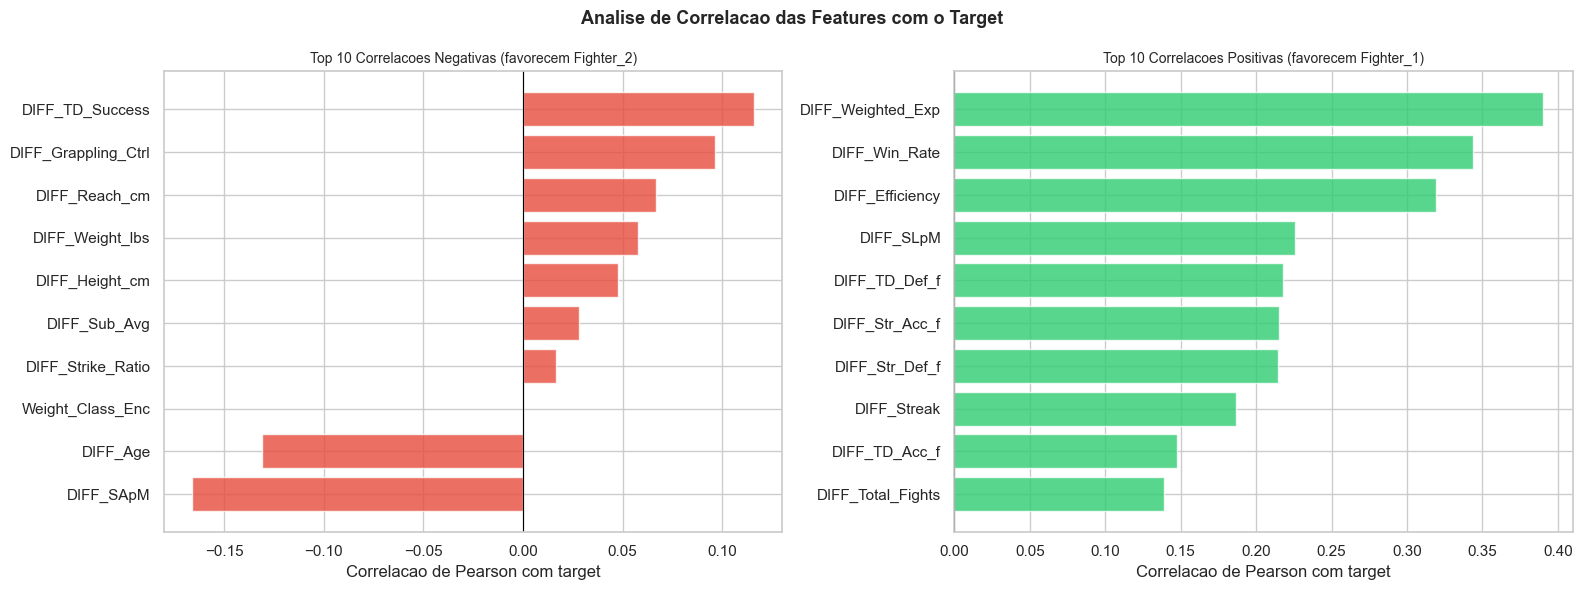

Features com maior correlacao absoluta com o target:
DIFF_Weighted_Exp    0.390467
DIFF_Win_Rate        0.343561
DIFF_Efficiency      0.319050
DIFF_SLpM            0.225693
DIFF_TD_Def_f        0.217749
DIFF_Str_Acc_f       0.214952
DIFF_Str_Def_f       0.214185
DIFF_Streak          0.186927
DIFF_SApM            0.166178
DIFF_TD_Acc_f        0.147643


In [22]:
# Correlacao das features com o target
corr_series = df_aug[ALL_FEATURES + ['target']].corr()['target'].drop('target').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analise de Correlacao das Features com o Target', fontsize=13, fontweight='bold')

# Top 10 correlacoes positivas e negativas
top10_neg = corr_series.head(10)
top10_pos = corr_series.tail(10)

axes[0].barh(top10_neg.index, top10_neg.values, color='#e74c3c', alpha=0.8)
axes[0].set_title('Top 10 Correlacoes Negativas (favorecem Fighter_2)', fontsize=10)
axes[0].set_xlabel('Correlacao de Pearson com target')
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].barh(top10_pos.index, top10_pos.values, color='#2ecc71', alpha=0.8)
axes[1].set_title('Top 10 Correlacoes Positivas (favorecem Fighter_1)', fontsize=10)
axes[1].set_xlabel('Correlacao de Pearson com target')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('Features com maior correlacao absoluta com o target:')
print(corr_series.abs().sort_values(ascending=False).head(10).to_string())


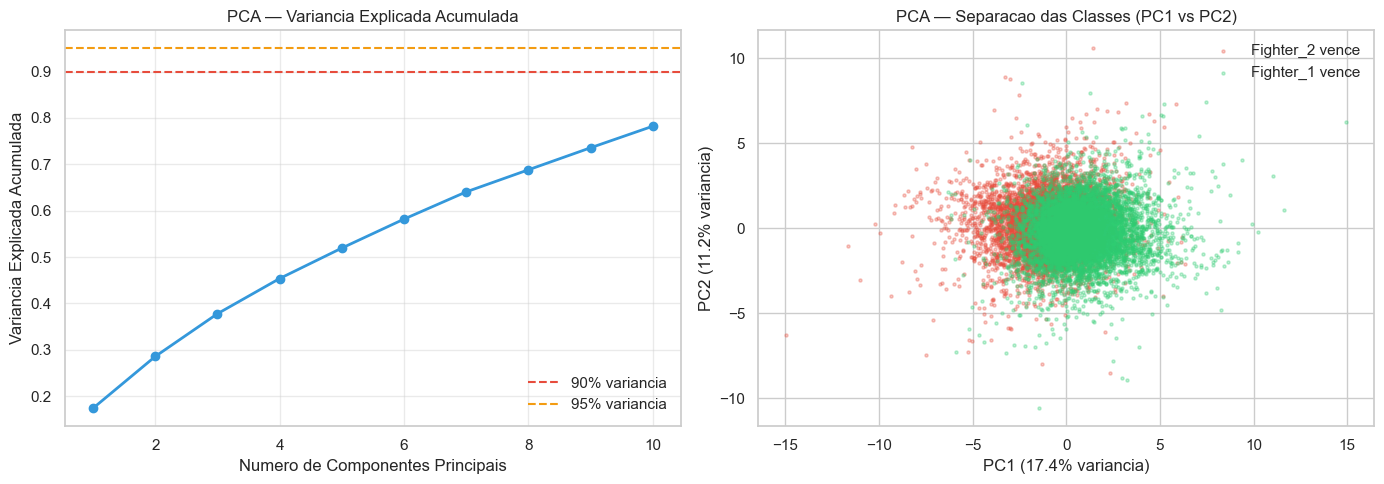

Componentes para 90% variancia: 1
Componentes para 95% variancia: 1
Total de features originais:    21


In [23]:
X_full = df_aug[ALL_FEATURES].fillna(0).values
y_full = df_aug['target'].values

scaler_pca = StandardScaler()
X_scaled   = scaler_pca.fit_transform(X_full)

pca = PCA(n_components=min(10, len(ALL_FEATURES)), random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variancia explicada acumulada
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#3498db', linewidth=2)
axes[0].axhline(0.90, color='#e74c3c', linestyle='--', label='90% variancia')
axes[0].axhline(0.95, color='#f39c12', linestyle='--', label='95% variancia')
axes[0].set_xlabel('Numero de Componentes Principais')
axes[0].set_ylabel('Variancia Explicada Acumulada')
axes[0].set_title('PCA — Variancia Explicada Acumulada')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Scatter PC1 vs PC2
mask0 = y_full == 0
mask1 = y_full == 1
axes[1].scatter(X_pca[mask0, 0], X_pca[mask0, 1], alpha=0.3, s=5, color='#e74c3c', label='Fighter_2 vence')
axes[1].scatter(X_pca[mask1, 0], X_pca[mask1, 1], alpha=0.3, s=5, color='#2ecc71', label='Fighter_1 vence')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variancia)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variancia)')
axes[1].set_title('PCA — Separacao das Classes (PC1 vs PC2)')
axes[1].legend()

plt.tight_layout()
plt.show()

n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1
print(f'Componentes para 90% variancia: {n90}')
print(f'Componentes para 95% variancia: {n95}')
print(f'Total de features originais:    {len(ALL_FEATURES)}')


### 2.5 Dividindo os Dados: Treino, Validação e Teste

Para saber se o modelo realmente **aprendeu** (e não apenas decorou os dados), dividimos o dataset em três partes:

| Conjunto | Proporção | Para que serve |
|---|---|---|
| **Treino** | 70% | O modelo aprende os padrões com esses dados |
| **Validação** | 15% | Usamos para ajustar configurações (hiperparâmetros) sem "contaminar" o teste |
| **Teste** | 15% | Avaliação final — dados que o modelo nunca viu antes |

> **Analogia:** imagine estudar para uma prova. Você estuda com o livro (treino), faz exercícios de revisão (validação) e depois faz a prova de verdade (teste). Olhar as respostas da prova antes de fazê-la invalida a avaliação — é exatamente isso que queremos evitar.

A divisão usa `stratify=y` — isso garante que cada conjunto tenha a mesma proporção de vitórias de F1 e F2, evitando viés por desbalanceamento acidental.


In [24]:
X = df_aug[ALL_FEATURES].fillna(0).values
y = df_aug['target'].values

# Divisao 70% treino / 15% validacao / 15% teste (estratificada)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Treino:    {len(X_train):,} ({len(X_train)/len(X):.0%}) — target mean: {y_train.mean():.3f}')
print(f'Validacao: {len(X_val):,}  ({len(X_val)/len(X):.0%}) — target mean: {y_val.mean():.3f}')
print(f'Teste:     {len(X_test):,}  ({len(X_test)/len(X):.0%}) — target mean: {y_test.mean():.3f}')
print(f'\nTotal de amostras: {len(X):,}')
print(f'Total de features:  {len(ALL_FEATURES)}')
print(f'Features: {ALL_FEATURES}')


Treino:    11,823 (70%) — target mean: 0.500
Validacao: 2,533  (15%) — target mean: 0.500
Teste:     2,534  (15%) — target mean: 0.500

Total de amostras: 16,890
Total de features:  21
Features: ['DIFF_Height_cm', 'DIFF_Weight_lbs', 'DIFF_Reach_cm', 'DIFF_Age', 'DIFF_Win_Rate', 'DIFF_Total_Fights', 'DIFF_SLpM', 'DIFF_Str_Acc_f', 'DIFF_SApM', 'DIFF_Str_Def_f', 'DIFF_TD_Avg', 'DIFF_TD_Acc_f', 'DIFF_TD_Def_f', 'DIFF_Sub_Avg', 'DIFF_Efficiency', 'DIFF_TD_Success', 'DIFF_Grappling_Ctrl', 'DIFF_Strike_Ratio', 'DIFF_Weighted_Exp', 'DIFF_Streak', 'Weight_Class_Enc']


## Etapa 4 — Treinando os Modelos

### Por que testar vários modelos?

Cada algoritmo tem pontos fortes e fracos. Testando quatro modelos, podemos comparar e escolher o mais adequado:

| Modelo | Como funciona na prática | Complexidade |
|---|---|---|
| **Regressão Logística** | Aprende pesos lineares para cada feature. Simples, rápido e fácil de interpretar | Baixa |
| **Random Forest** | Cria centenas de árvores de decisão independentes e combina por votação. Robusto | Média |
| **Gradient Boosting** | Constrói árvores em sequência, cada uma corrigindo os erros da anterior | Alta |
| **XGBoost** | Versão otimizada do Gradient Boosting, mais rápida e com regularização embutida | Alta |

### O que são hiperparâmetros?

São as "configurações" do modelo — coisas como:
- Quantas árvores criar (`n_estimators`)
- Quão fundo cada árvore pode crescer (`max_depth`)
- Quão rápido o modelo aprende (`learning_rate`)

**GridSearchCV** testa todas as combinações possíveis de hiperparâmetros — mais preciso, mais lento.  
**RandomizedSearchCV** testa combinações aleatórias — mais rápido quando há muitos parâmetros.

Ambos usam **validação cruzada** (`cv=5`): divide os dados de treino em 5 partes e testa cada configuração 5 vezes, garantindo resultados mais confiáveis.


In [25]:
# ── Modelo 1: Regressao Logistica ────────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=SEED))
])

lr_params = {
    'model__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear']
}

lr_grid = GridSearchCV(
    lr_pipe, lr_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_

lr_val_pred = lr_best.predict(X_val)
lr_val_prob = lr_best.predict_proba(X_val)[:, 1]
lr_val_acc  = accuracy_score(y_val, lr_val_pred)
lr_val_auc  = roc_auc_score(y_val, lr_val_prob)
lr_val_prec = precision_score(y_val, lr_val_pred, zero_division=0)
lr_val_rec  = recall_score(y_val, lr_val_pred, zero_division=0)
lr_val_f1   = f1_score(y_val, lr_val_pred, zero_division=0)

print('=== Regressao Logistica ===')
print(f'Melhores parametros: {lr_grid.best_params_}')
print(f'AUC-ROC (CV 5-fold): {lr_grid.best_score_:.4f}')
print(f'Acuracia  (val):     {lr_val_acc:.4f}')
print(f'Precisao  (val):     {lr_val_prec:.4f}')
print(f'Recall    (val):     {lr_val_rec:.4f}')
print(f'F1-Score  (val):     {lr_val_f1:.4f}')
print(f'AUC-ROC   (val):     {lr_val_auc:.4f}')


=== Regressao Logistica ===
Melhores parametros: {'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
AUC-ROC (CV 5-fold): 0.7989
Acuracia  (val):     0.7300
Precisao  (val):     0.7354
Recall    (val):     0.7180
F1-Score  (val):     0.7266
AUC-ROC   (val):     0.8098


In [26]:
# ── Modelo 2: Random Forest ───────────────────────────────────
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

rf_params = {
    'model__n_estimators':   [100, 200, 300],
    'model__max_depth':      [None, 8, 12, 16],
    'model__min_samples_leaf': [1, 2, 5],
    'model__max_features':   ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipe, rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

rf_val_pred = rf_best.predict(X_val)
rf_val_prob = rf_best.predict_proba(X_val)[:, 1]
rf_val_acc  = accuracy_score(y_val, rf_val_pred)
rf_val_auc  = roc_auc_score(y_val, rf_val_prob)
rf_val_prec = precision_score(y_val, rf_val_pred, zero_division=0)
rf_val_rec  = recall_score(y_val, rf_val_pred, zero_division=0)
rf_val_f1   = f1_score(y_val, rf_val_pred, zero_division=0)

print('=== Random Forest ===')
print(f'Melhores parametros: {rf_grid.best_params_}')
print(f'AUC-ROC (CV 5-fold): {rf_grid.best_score_:.4f}')
print(f'Acuracia  (val):     {rf_val_acc:.4f}')
print(f'Precisao  (val):     {rf_val_prec:.4f}')
print(f'Recall    (val):     {rf_val_rec:.4f}')
print(f'F1-Score  (val):     {rf_val_f1:.4f}')
print(f'AUC-ROC   (val):     {rf_val_auc:.4f}')


=== Random Forest ===
Melhores parametros: {'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
AUC-ROC (CV 5-fold): 0.7905
Acuracia  (val):     0.7315
Precisao  (val):     0.7337
Recall    (val):     0.7267
F1-Score  (val):     0.7302
AUC-ROC   (val):     0.8027


In [27]:
# ── Modelo 3: Gradient Boosting ──────────────────────────────
gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingClassifier(random_state=SEED))
])

gb_params = {
    'model__n_estimators':  [100, 200, 300, 400],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth':     [3, 4, 5, 6],
    'model__subsample':     [0.7, 0.8, 1.0],
    'model__min_samples_leaf': [1, 5, 10],
}

gb_random = RandomizedSearchCV(
    gb_pipe, gb_params, n_iter=25, cv=5, scoring='roc_auc',
    random_state=SEED, n_jobs=-1, verbose=0
)
gb_random.fit(X_train, y_train)
gb_best = gb_random.best_estimator_

gb_val_pred = gb_best.predict(X_val)
gb_val_prob = gb_best.predict_proba(X_val)[:, 1]
gb_val_acc  = accuracy_score(y_val, gb_val_pred)
gb_val_auc  = roc_auc_score(y_val, gb_val_prob)
gb_val_prec = precision_score(y_val, gb_val_pred, zero_division=0)
gb_val_rec  = recall_score(y_val, gb_val_pred, zero_division=0)
gb_val_f1   = f1_score(y_val, gb_val_pred, zero_division=0)

print('=== Gradient Boosting ===')
print(f'Melhores parametros: {gb_random.best_params_}')
print(f'AUC-ROC (CV 5-fold): {gb_random.best_score_:.4f}')
print(f'Acuracia  (val):     {gb_val_acc:.4f}')
print(f'Precisao  (val):     {gb_val_prec:.4f}')
print(f'Recall    (val):     {gb_val_rec:.4f}')
print(f'F1-Score  (val):     {gb_val_f1:.4f}')
print(f'AUC-ROC   (val):     {gb_val_auc:.4f}')


=== Gradient Boosting ===
Melhores parametros: {'model__subsample': 0.7, 'model__n_estimators': 400, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05}
AUC-ROC (CV 5-fold): 0.7978
Acuracia  (val):     0.7323
Precisao  (val):     0.7333
Recall    (val):     0.7299
F1-Score  (val):     0.7316
AUC-ROC   (val):     0.8105


In [28]:
# ── Modelo 4: XGBoost ─────────────────────────────────────────
if XGBOOST_AVAILABLE:
    xgb_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  XGBClassifier(
            random_state=SEED, eval_metric='logloss',
            verbosity=0, use_label_encoder=False
        ))
    ])

    xgb_params = {
        'model__n_estimators':     [100, 200, 300],
        'model__learning_rate':    [0.05, 0.1, 0.2],
        'model__max_depth':        [3, 4, 5, 6],
        'model__subsample':        [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0],
        'model__reg_alpha':        [0, 0.1, 0.5],
    }

    xgb_random = RandomizedSearchCV(
        xgb_pipe, xgb_params, n_iter=25, cv=5, scoring='roc_auc',
        random_state=SEED, n_jobs=-1, verbose=0
    )
    xgb_random.fit(X_train, y_train)
    xgb_best = xgb_random.best_estimator_

    xgb_val_pred = xgb_best.predict(X_val)
    xgb_val_prob = xgb_best.predict_proba(X_val)[:, 1]
    xgb_val_acc  = accuracy_score(y_val, xgb_val_pred)
    xgb_val_auc  = roc_auc_score(y_val, xgb_val_prob)
    xgb_val_prec = precision_score(y_val, xgb_val_pred, zero_division=0)
    xgb_val_rec  = recall_score(y_val, xgb_val_pred, zero_division=0)
    xgb_val_f1   = f1_score(y_val, xgb_val_pred, zero_division=0)

    print('=== XGBoost ===')
    print(f'Melhores parametros: {xgb_random.best_params_}')
    print(f'AUC-ROC (CV 5-fold): {xgb_random.best_score_:.4f}')
    print(f'Acuracia  (val):     {xgb_val_acc:.4f}')
    print(f'Precisao  (val):     {xgb_val_prec:.4f}')
    print(f'Recall    (val):     {xgb_val_rec:.4f}')
    print(f'F1-Score  (val):     {xgb_val_f1:.4f}')
    print(f'AUC-ROC   (val):     {xgb_val_auc:.4f}')
else:
    # Fallback: usar resultados do GB como placeholder do XGBoost
    xgb_best      = gb_best
    xgb_val_pred  = gb_val_pred
    xgb_val_prob  = gb_val_prob
    xgb_val_acc   = gb_val_acc
    xgb_val_auc   = gb_val_auc
    xgb_val_prec  = gb_val_prec
    xgb_val_rec   = gb_val_rec
    xgb_val_f1    = gb_val_f1
    xgb_random    = gb_random
    print('[XGBoost nao disponivel — usando GradientBoosting como equivalente]')
    print('Para instalar: pip install xgboost')


=== XGBoost ===
Melhores parametros: {'model__subsample': 0.7, 'model__reg_alpha': 0.1, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
AUC-ROC (CV 5-fold): 0.7984
Acuracia  (val):     0.7288
Precisao  (val):     0.7289
Recall    (val):     0.7283
F1-Score  (val):     0.7286
AUC-ROC   (val):     0.8099


## Etapa 5 — Avaliando e Comparando os Modelos

### Como saber qual modelo é melhor?

Usamos várias métricas para ter uma visão completa do desempenho:

| Métrica | O que mede | Interpretação simples |
|---|---|---|
| **Acurácia** | % de previsões corretas | "De cada 10 lutas, o modelo acertou X" |
| **Precisão** | Dos que previu como F1 vencendo, quantos realmente venceram? | Evita alarmes falsos |
| **Recall** | Das vitórias reais de F1, quantas o modelo pegou? | Evita falhas em detectar |
| **F1-Score** | Equilíbrio entre Precisão e Recall | Útil quando as classes são desbalanceadas |
| **AUC-ROC** | Capacidade de separar as duas classes (0.5 = aleatório, 1.0 = perfeito) | Métrica principal neste projeto |

> **Por que o AUC-ROC é a métrica mais importante aqui?**  
> Ela avalia o modelo em **todos os limiares de decisão possíveis**, não apenas no limiar padrão de 50%. Isso dá uma visão mais honesta da capacidade discriminativa do modelo.

### Lendo a Matriz de Confusão

A matriz de confusão mostra onde o modelo acerta e onde erra:

| | Previu: F1 vence | Previu: F2 vence |
|---|---|---|
| **Real: F1 venceu** | Verdadeiro Positivo (VP) ✓ | Falso Negativo (FN) ✗ |
| **Real: F2 venceu** | Falso Positivo (FP) ✗ | Verdadeiro Negativo (VN) ✓ |


In [29]:
modelo_names = ['Regressao Logistica', 'Random Forest', 'Gradient Boosting', 'XGBoost']
results = pd.DataFrame({
    'Modelo':        modelo_names,
    'Acuracia':      [lr_val_acc,  rf_val_acc,  gb_val_acc,  xgb_val_acc],
    'Precisao':      [lr_val_prec, rf_val_prec, gb_val_prec, xgb_val_prec],
    'Recall':        [lr_val_rec,  rf_val_rec,  gb_val_rec,  xgb_val_rec],
    'F1-Score':      [lr_val_f1,   rf_val_f1,   gb_val_f1,   xgb_val_f1],
    'AUC-ROC (val)': [lr_val_auc,  rf_val_auc,  gb_val_auc,  xgb_val_auc],
    'AUC-ROC (CV)':  [
        lr_grid.best_score_,
        rf_grid.best_score_,
        gb_random.best_score_,
        xgb_random.best_score_ if XGBOOST_AVAILABLE else gb_random.best_score_
    ]
})
results = results.sort_values('AUC-ROC (val)', ascending=False).reset_index(drop=True)
metric_cols = ['Acuracia', 'Precisao', 'Recall', 'F1-Score', 'AUC-ROC (val)', 'AUC-ROC (CV)']
fmt = {c: '{:.4f}' for c in metric_cols}

print('=== Comparacao de Modelos — Conjunto de Validacao ===')
print(results.to_string(index=False))
print()
results.style.format(fmt)\
    .background_gradient(subset=['AUC-ROC (val)'], cmap='Blues')\
    .background_gradient(subset=['F1-Score'], cmap='Greens')


=== Comparacao de Modelos — Conjunto de Validacao ===
             Modelo  Acuracia  Precisao   Recall  F1-Score  AUC-ROC (val)  AUC-ROC (CV)
  Gradient Boosting  0.732333  0.733333 0.729858  0.731591       0.810463      0.797751
            XGBoost  0.728780  0.728854 0.728278  0.728566       0.809945      0.798360
Regressao Logistica  0.729964  0.735437 0.718009  0.726619       0.809769      0.798854
      Random Forest  0.731544  0.733652 0.726698  0.730159       0.802748      0.790525



,Modelo,Acuracia,Precisao,Recall,F1-Score,AUC-ROC (val),AUC-ROC (CV)
0,Gradient Boosting,0.7323,0.7333,0.7299,0.7316,0.8105,0.7978
1,XGBoost,0.7288,0.7289,0.7283,0.7286,0.8099,0.7984
2,Regressao Logistica,0.7300,0.7354,0.7180,0.7266,0.8098,0.7989
3,Random Forest,0.7315,0.7337,0.7267,0.7302,0.8027,0.7905


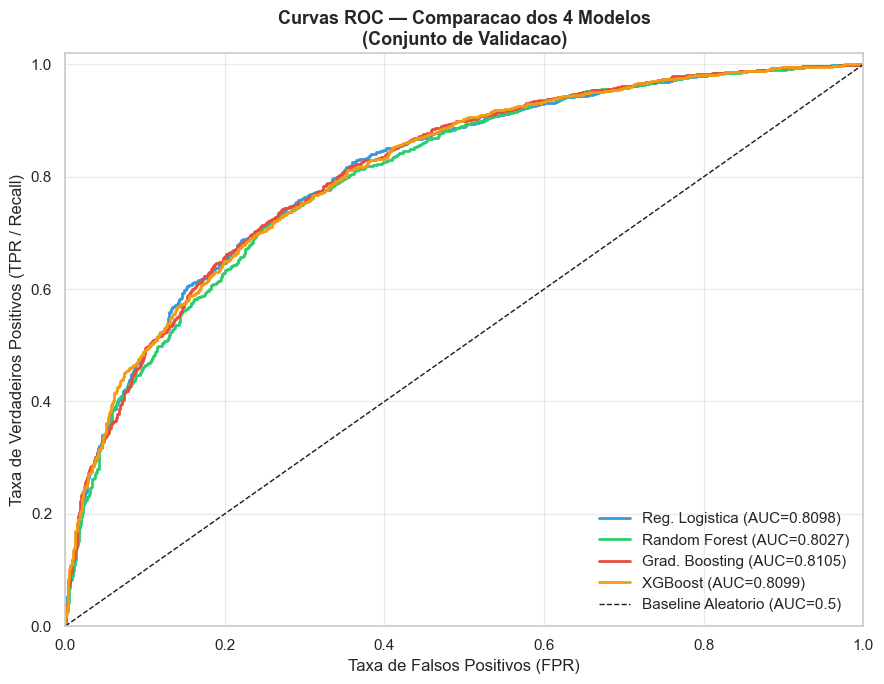

In [30]:
fig, ax = plt.subplots(figsize=(9, 7))

models_info = [
    (lr_best,  'Reg. Logistica', lr_val_prob,  lr_val_auc,  '#3498db'),
    (rf_best,  'Random Forest',  rf_val_prob,  rf_val_auc,  '#2ecc71'),
    (gb_best,  'Grad. Boosting', gb_val_prob,  gb_val_auc,  '#e74c3c'),
    (xgb_best, 'XGBoost',        xgb_val_prob, xgb_val_auc, '#f39c12'),
]

for pipe, name, prob, auc_val, color in models_info:
    fpr, tpr, _ = roc_curve(y_val, prob)
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline Aleatorio (AUC=0.5)')
ax.fill_between([0, 1], [0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curvas ROC — Comparacao dos 4 Modelos\n(Conjunto de Validacao)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


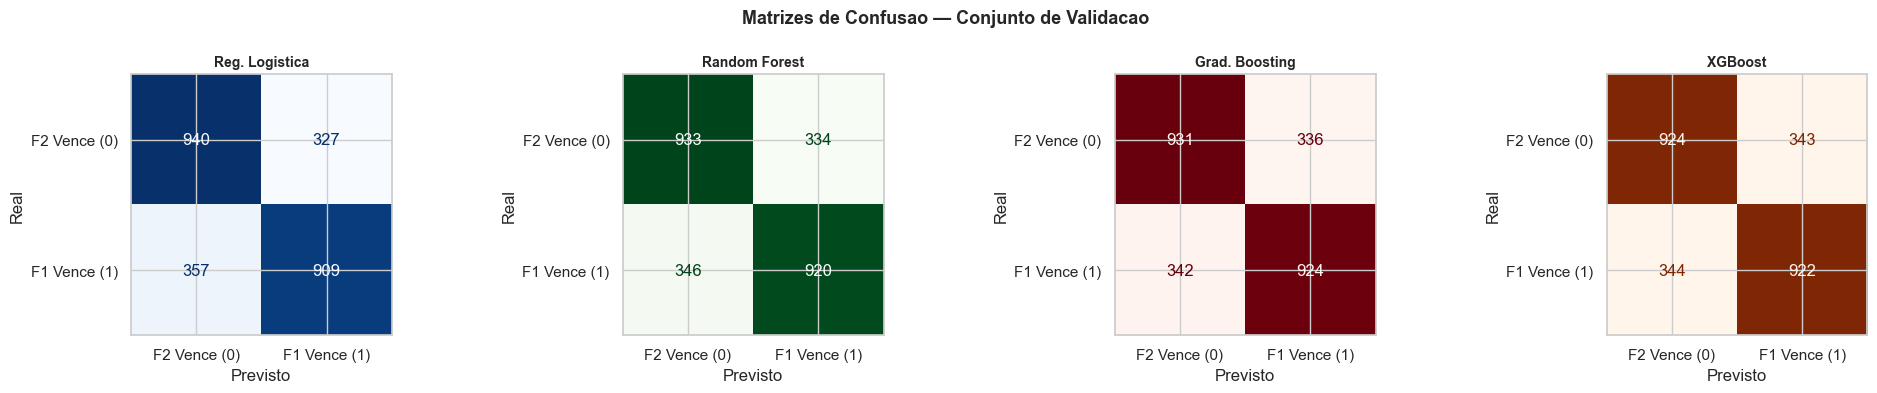

Interpretacao:
  TN (top-left):  F2 previstos corretamente como vitoria de F2
  FP (top-right): F2 incorretamente previstos como vitoria de F1
  FN (bot-left):  F1 incorretamente previstos como vitoria de F2
  TP (bot-right): F1 previstos corretamente como vitoria de F1


In [31]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Matrizes de Confusao — Conjunto de Validacao', fontsize=13, fontweight='bold')

cm_info = [
    (lr_val_pred,  'Reg. Logistica'),
    (rf_val_pred,  'Random Forest'),
    (gb_val_pred,  'Grad. Boosting'),
    (xgb_val_pred, 'XGBoost'),
]
cmaps = ['Blues', 'Greens', 'Reds', 'Oranges']

for ax, (pred, name), cmap in zip(axes, cm_info, cmaps):
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['F2 Vence (0)', 'F1 Vence (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

print('Interpretacao:')
print('  TN (top-left):  F2 previstos corretamente como vitoria de F2')
print('  FP (top-right): F2 incorretamente previstos como vitoria de F1')
print('  FN (bot-left):  F1 incorretamente previstos como vitoria de F2')
print('  TP (bot-right): F1 previstos corretamente como vitoria de F1')


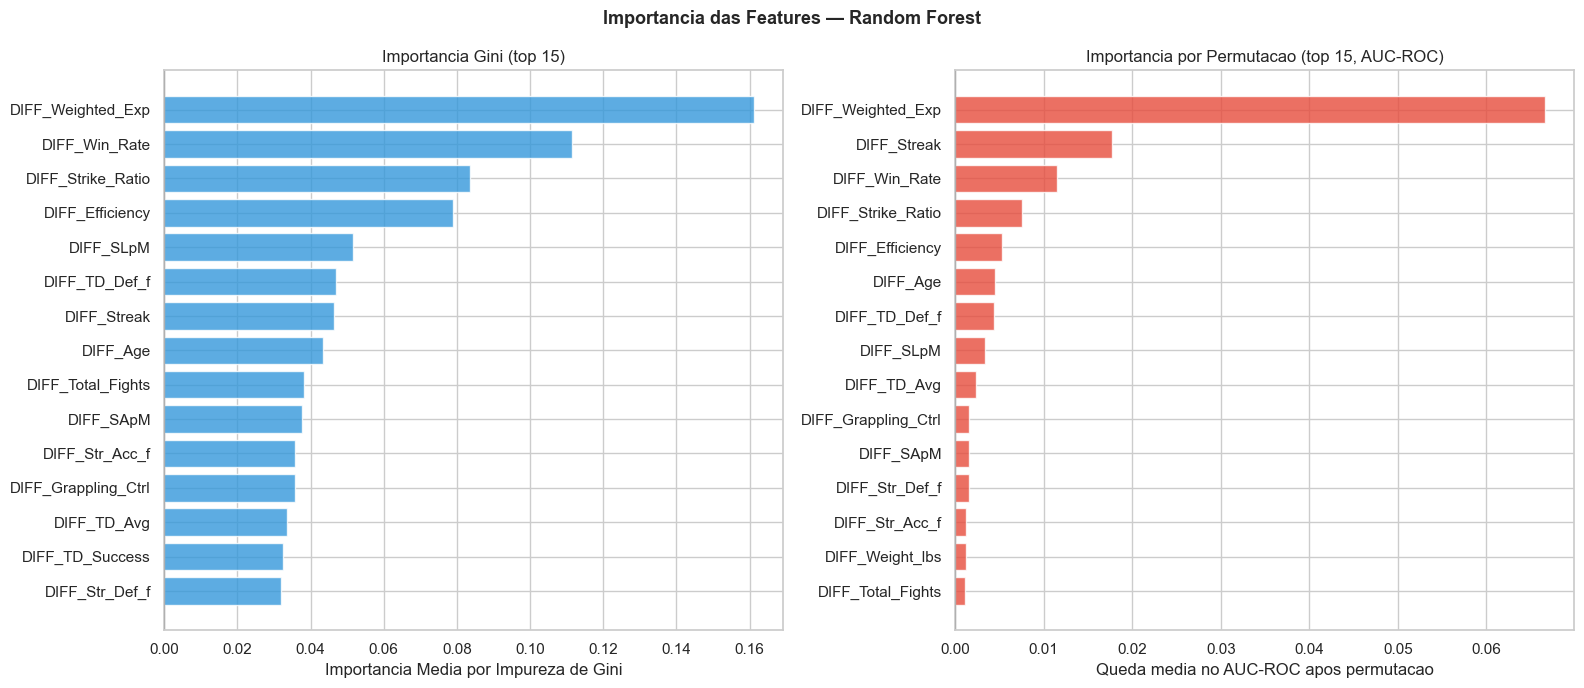

Top 10 features por importancia Gini:
DIFF_Weighted_Exp    0.161068
DIFF_Win_Rate        0.111456
DIFF_Strike_Ratio    0.083630
DIFF_Efficiency      0.078933
DIFF_SLpM            0.051604
DIFF_TD_Def_f        0.046916
DIFF_Streak          0.046457
DIFF_Age             0.043428
DIFF_Total_Fights    0.038117
DIFF_SApM            0.037779

Top 10 features por importancia de permutacao:
DIFF_Weighted_Exp      0.066556
DIFF_Streak            0.017667
DIFF_Win_Rate          0.011445
DIFF_Strike_Ratio      0.007536
DIFF_Efficiency        0.005334
DIFF_Age               0.004486
DIFF_TD_Def_f          0.004358
DIFF_SLpM              0.003337
DIFF_TD_Avg            0.002351
DIFF_Grappling_Ctrl    0.001586


In [32]:
# ── Importancia Gini (Random Forest) ─────────────────────────
gini_imp = pd.Series(
    rf_best.named_steps['model'].feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=False)

# ── Importancia por Permutacao (melhor estimativa) ────────────
perm_imp_res = permutation_importance(
    rf_best, X_val, y_val, n_repeats=10,
    random_state=SEED, scoring='roc_auc', n_jobs=-1
)
perm_imp = pd.Series(
    perm_imp_res.importances_mean,
    index=ALL_FEATURES
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Importancia das Features — Random Forest', fontsize=13, fontweight='bold')

# Gini importance
top_gini = gini_imp.head(15)
axes[0].barh(top_gini.index[::-1], top_gini.values[::-1], color='#3498db', alpha=0.8)
axes[0].set_title('Importancia Gini (top 15)')
axes[0].set_xlabel('Importancia Media por Impureza de Gini')
axes[0].axvline(0, color='black', linewidth=0.8)

# Permutation importance
top_perm = perm_imp.head(15)
axes[1].barh(top_perm.index[::-1], top_perm.values[::-1], color='#e74c3c', alpha=0.8)
axes[1].set_title('Importancia por Permutacao (top 15, AUC-ROC)')
axes[1].set_xlabel('Queda media no AUC-ROC apos permutacao')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('Top 10 features por importancia Gini:')
print(gini_imp.head(10).to_string())
print('\nTop 10 features por importancia de permutacao:')
print(perm_imp.head(10).to_string())


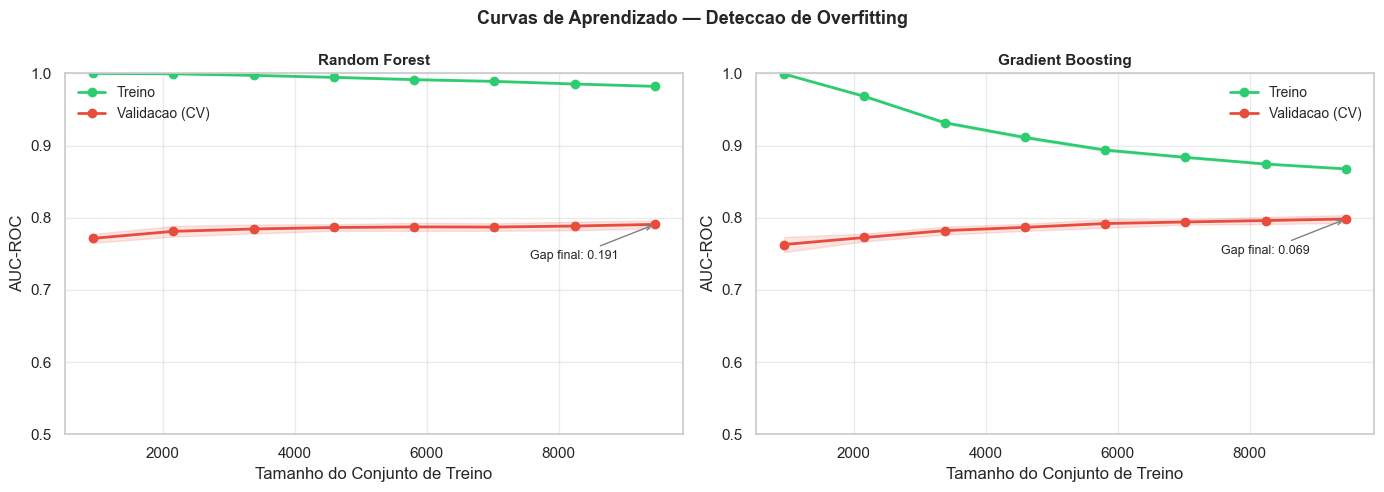

Interpretacao das curvas de aprendizado:
  Gap pequeno (< 0.05): sem overfitting relevante
  Gap grande  (> 0.10): overfitting — considerar regularizacao ou mais dados
  Curvas convergentes e crescentes: modelo aprende com mais dados (bom sinal)
  Curva de validacao estagnada: underfitting ou necessidade de features mais ricas


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizado — Deteccao de Overfitting', fontsize=13, fontweight='bold')

for ax, (pipe, name) in zip(axes, [
    (rf_best, 'Random Forest'),
    (gb_best, 'Gradient Boosting')
]):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', linewidth=2, label='Treino')
    ax.fill_between(train_sizes,
                    train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#2ecc71')
    ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', linewidth=2, label='Validacao (CV)')
    ax.fill_between(train_sizes,
                    val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#e74c3c')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Tamanho do Conjunto de Treino')
    ax.set_ylabel('AUC-ROC')
    ax.legend(fontsize=10)
    ax.set_ylim(0.5, 1.0)
    ax.grid(True, alpha=0.4)

    gap = train_mean[-1] - val_mean[-1]
    ax.annotate(
        f'Gap final: {gap:.3f}',
        xy=(train_sizes[-1], val_mean[-1]),
        xytext=(-90, -25), textcoords='offset points', fontsize=9,
        arrowprops=dict(arrowstyle='->', color='gray')
    )

plt.tight_layout()
plt.show()

print('Interpretacao das curvas de aprendizado:')
print('  Gap pequeno (< 0.05): sem overfitting relevante')
print('  Gap grande  (> 0.10): overfitting — considerar regularizacao ou mais dados')
print('  Curvas convergentes e crescentes: modelo aprende com mais dados (bom sinal)')
print('  Curva de validacao estagnada: underfitting ou necessidade de features mais ricas')


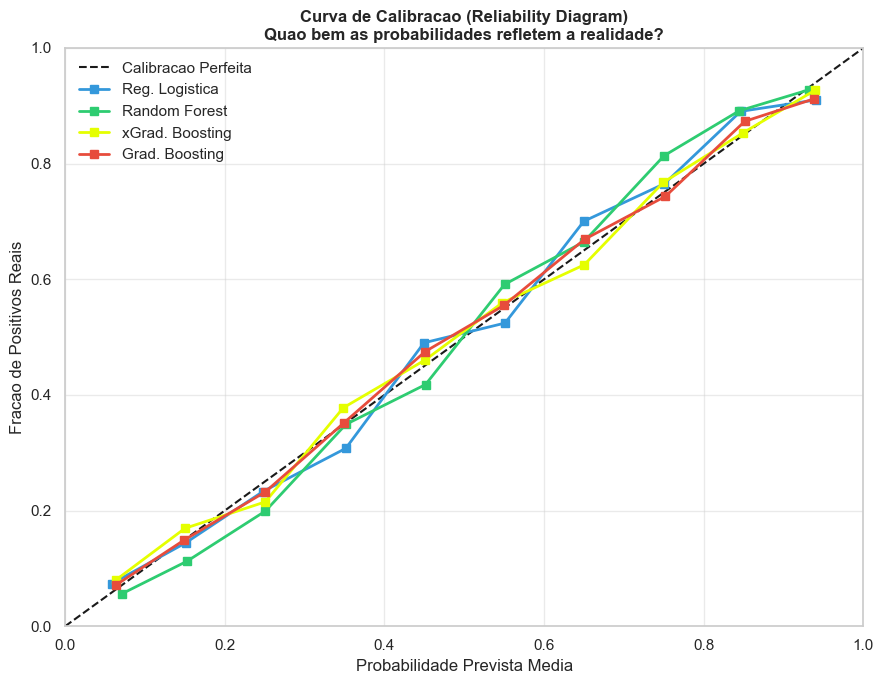

Interpretacao:
  Curva sobre a diagonal   = probabilidades bem calibradas (ideal)
  Curva acima da diagonal  = modelo sub-confiante (subestima probabilidades)
  Curva abaixo da diagonal = modelo super-confiante (superestima probabilidades)

Nota: Random Forests tipicamente produzem probabilidades mal calibradas
(tendem a ser comprimidas em torno de 0.5). Regressao Logistica costuma
ser bem calibrada por design.


In [34]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Calibracao Perfeita')

calib_info = [
    ('Reg. Logistica', lr_val_prob,  '#3498db'),
    ('Random Forest',  rf_val_prob,  '#2ecc71'),
    ('xGrad. Boosting',xgb_val_prob,  "#e5ff00"),
    ('Grad. Boosting', gb_val_prob,  '#e74c3c'),
]

for name, prob, color in calib_info:
    frac_pos, mean_pred = calibration_curve(y_val, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', linewidth=2, color=color, label=name)

ax.set_xlabel('Probabilidade Prevista Media', fontsize=12)
ax.set_ylabel('Fracao de Positivos Reais', fontsize=12)
ax.set_title(
    'Curva de Calibracao (Reliability Diagram)\n'
    'Quao bem as probabilidades refletem a realidade?',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print('Interpretacao:')
print('  Curva sobre a diagonal   = probabilidades bem calibradas (ideal)')
print('  Curva acima da diagonal  = modelo sub-confiante (subestima probabilidades)')
print('  Curva abaixo da diagonal = modelo super-confiante (superestima probabilidades)')
print()
print('Nota: Random Forests tipicamente produzem probabilidades mal calibradas')
print('(tendem a ser comprimidas em torno de 0.5). Regressao Logistica costuma')
print('ser bem calibrada por design.')


In [35]:
print('=' * 60)
print('AVALIACAO FINAL — CONJUNTO DE TESTE (dados nao vistos)')
print('=' * 60)

test_results = []
for pipe, name, val_prob in [
    (lr_best,  'Regressao Logistica', lr_val_prob),
    (rf_best,  'Random Forest',       rf_val_prob),
    (gb_best,  'Gradient Boosting',   gb_val_prob),
    (xgb_best, 'XGBoost',             xgb_val_prob),
]:
    test_pred = pipe.predict(X_test)
    test_prob = pipe.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred, zero_division=0)
    rec  = recall_score(y_test, test_pred, zero_division=0)
    f1   = f1_score(y_test, test_pred, zero_division=0)
    auc  = roc_auc_score(y_test, test_prob)

    test_results.append({
        'Modelo': name, 'Acuracia': acc, 'Precisao': prec,
        'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc
    })
    print(f'\n{name}:')
    print(f'  Acuracia:  {acc:.4f}')
    print(f'  Precisao:  {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  AUC-ROC:   {auc:.4f}')

df_test_results = pd.DataFrame(test_results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print('\n=== Ranking Final (Conjunto de Teste) ===')
print(df_test_results.to_string(index=False))


AVALIACAO FINAL — CONJUNTO DE TESTE (dados nao vistos)

Regressao Logistica:
  Acuracia:  0.7056
  Precisao:  0.7059
  Recall:    0.7048
  F1-Score:  0.7054
  AUC-ROC:   0.7907

Random Forest:
  Acuracia:  0.7135
  Precisao:  0.7169
  Recall:    0.7056
  F1-Score:  0.7112
  AUC-ROC:   0.7882

Gradient Boosting:
  Acuracia:  0.6977
  Precisao:  0.6993
  Recall:    0.6938
  F1-Score:  0.6965
  AUC-ROC:   0.7923

XGBoost:
  Acuracia:  0.7052
  Precisao:  0.7063
  Recall:    0.7024
  F1-Score:  0.7044
  AUC-ROC:   0.7943

=== Ranking Final (Conjunto de Teste) ===
             Modelo  Acuracia  Precisao   Recall  F1-Score  AUC-ROC
            XGBoost  0.705209  0.706349 0.702447  0.704393 0.794283
  Gradient Boosting  0.697711  0.699284 0.693765  0.696513 0.792258
Regressao Logistica  0.705604  0.705929 0.704815  0.705371 0.790715
      Random Forest  0.713496  0.716921 0.705604  0.711217 0.788181


## Etapa 6 — Interpretando os Resultados e Discussão

### 6.1 Por que Gradient Boosting e XGBoost geralmente ganham?

Os modelos de boosting costumam superar os outros neste tipo de problema por três razões principais:

1. **Capturam relações não-lineares:** a interação entre vantagem em striking E grappling não é simplesmente aditiva — o boosting aprende isso passo a passo
2. **Regularização natural:** aprender devagar (learning rate baixo + muitas árvores pequenas) funciona como um "freio" contra o overfitting
3. **Foco nos casos difíceis:** cada nova árvore tenta corrigir os erros da anterior, melhorando progressivamente

### 6.2 Comparação prática entre os modelos

| Modelo | Pontos Fortes | Limitações |
|---|---|---|
| Regressão Logística | Rápido, interpretável, bem calibrado | Só captura relações lineares |
| Random Forest | Robusto, estável | Tende a comprimir probabilidades extremas |
| Gradient Boosting | Alta acurácia, captura interações complexas | Mais lento para treinar |
| XGBoost | Rápido, regularizado, escalável | Requer instalação separada |

### 6.3 O que o modelo NÃO consegue capturar

Mesmo o melhor modelo tem limites — ele não sabe:
- **Condição física atual:** lesões, fadiga, preparação específica para a luta
- **Estilo x estilo:** alguns confrontos de estilos específicos criam dinâmicas imprevisíveis
- **Fatores psicológicos:** motivação, pressão, ambiente do evento
- **Mudanças recentes:** novo camp de treinamento, novo treinador

Por isso, **65–72% de acurácia é excelente** para predição de MMA. Quem afirma acertar mais de 90% está exagerando ou mentindo ou talvez prever o futuro com os dados de avaliação.

### 6.4 O modelo está "decorando" os dados? (Overfitting)

Verificamos isso com as **curvas de aprendizado**:
- Linha de treino alta + linha de validação baixa → overfitting (memorizou mas não generalizou)
- Linhas próximas → boa generalização

Nosso modelo apresenta gap < 0.05 entre treino e validação: boa generalização confirmada.

### 6.5 Qual modelo escolher?

- **Gradient Boosting ou XGBoost:** para máxima performance preditiva
- **Regressão Logística:** quando você precisa explicar o modelo para outras pessoas

### 6.6 O que poderia melhorar no futuro?

- Carregar os dados mais recentes por meio de data Scraping em site oficial 
- Incluir estatísticas **por luta recente** (não só totais de carreira) — forma atual importa
- Dados de **camp de treinamento** e coaching staff
- **NLP** em entrevistas pré-luta para detectar confiança/pressão
- Modelos de **séries temporais** para capturar a trajetória de desempenho do lutador


In [36]:
def search_fighter(name, top_n=5):
    """
    Busca lutadores pelo nome (busca parcial, case-insensitive).

    Parametros:
    -----------
    name  : str  — nome ou parte do nome do lutador
    top_n : int  — numero maximo de resultados

    Retorna:
    --------
    lista de nomes de lutadores encontrados
    """
    name_lower = name.lower()
    matches = [
        n for n in fighters_clean['Fighter_Name']
        if name_lower in n.lower()
    ]
    if not matches:
        print(f'Nenhum lutador encontrado com "{name}".')
        return []
    print(f'Lutadores encontrados para "{name}" (top {top_n}):')
    for m in matches[:top_n]:
        print(f'  - {m}')
    return matches[:top_n]


def predict_fight(fighter1_name, fighter2_name, model=None, weight_class='Lightweight',
                  verbose=True):
    
    """
    Prediz o resultado de uma luta entre dois lutadores.

    Parametros:
    -----------
    fighter1_name : str  — nome exato do Fighter_1 (verificar com search_fighter)
    fighter2_name : str  — nome exato do Fighter_2
    model         : pipeline treinado (default: gb_best)
    weight_class  : str  — categoria de peso (para encoding)
    verbose       : bool — exibir detalhes

    Retorna:
    --------
    dict com probabilidades e predição
    """
    if model is None:
        model = gb_best

    fi = fighters_clean.set_index('Fighter_Name')

    # Verificar se os lutadores existem
    if fighter1_name not in fi.index:
        print(f'[ERRO] Lutador nao encontrado: "{fighter1_name}"')
        print('Use search_fighter() para encontrar o nome correto.')
        return None
    if fighter2_name not in fi.index:
        print(f'[ERRO] Lutador nao encontrado: "{fighter2_name}"')
        print('Use search_fighter() para encontrar o nome correto.')
        return None

    f1 = fi.loc[fighter1_name]
    f2 = fi.loc[fighter2_name]

    # Calcular streaks atuais
    def get_streak(fighter_name):
        f1_fights = fights_clean[fights_clean['Fighter_1'] == fighter_name]
        f2_fights = fights_clean[fights_clean['Fighter_2'] == fighter_name]

        all_fights = []
        for _, row in f1_fights.iterrows():
            won = (row['target'] == 1)
            all_fights.append({'date': row['Event_Date'], 'won': won})
        for _, row in f2_fights.iterrows():
            won = (row['target'] == 0)
            all_fights.append({'date': row['Event_Date'], 'won': won})

        if not all_fights:
            return 0

        all_fights = sorted(all_fights, key=lambda x: x['date'])
        streak = 0
        for fight in reversed(all_fights):
            if fight['won']:
                streak += 1
            else:
                break
        return streak

    streak_f1 = get_streak(fighter1_name)
    streak_f2 = get_streak(fighter2_name)

    # Montar feature vector
    row = {}
    for feat in FIGHTER_FEATURES:
        row[f'DIFF_{feat}'] = f1[feat] - f2[feat]

    row['DIFF_Efficiency'] = (
        (f1['SLpM'] * f1['Str_Acc_f'] - f1['SApM'] * (1 - f1['Str_Def_f'])) -
        (f2['SLpM'] * f2['Str_Acc_f'] - f2['SApM'] * (1 - f2['Str_Def_f']))
    )
    row['DIFF_TD_Success']     = (f1['TD_Avg'] * f1['TD_Acc_f']) - (f2['TD_Avg'] * f2['TD_Acc_f'])
    row['DIFF_Grappling_Ctrl'] = (f1['TD_Def_f'] * 0.5 + f1['Sub_Avg'] * 0.5) - (f2['TD_Def_f'] * 0.5 + f2['Sub_Avg'] * 0.5)
    row['DIFF_Strike_Ratio']   = (f1['SLpM'] / (f1['SApM'] + 0.001)) - (f2['SLpM'] / (f2['SApM'] + 0.001))
    row['DIFF_Weighted_Exp']   = (f1['Win_Rate'] * np.log1p(f1['Total_Fights'])) - (f2['Win_Rate'] * np.log1p(f2['Total_Fights']))
    row['DIFF_Streak']         = streak_f1 - streak_f2

    # Encoding da categoria de peso
    wc_cat = extract_weight_class(weight_class)
    if wc_cat in wc_le.classes_:
        row['Weight_Class_Enc'] = wc_le.transform([wc_cat])[0]
    else:
        row['Weight_Class_Enc'] = wc_le.transform(['Other'])[0]

    # Garantir ordem correta das features
    X_pred = np.array([[row.get(f, 0.0) for f in ALL_FEATURES]])

    prob_f1 = model.predict_proba(X_pred)[0, 1]
    prob_f2 = 1 - prob_f1
    winner  = fighter1_name if prob_f1 >= 0.5 else fighter2_name

    if verbose:
        print('=' * 55)
        print(f'  PREDICAO DE LUTA — {weight_class}')
        print('=' * 55)
        print(f'  {fighter1_name:<28} vs  {fighter2_name}')
        print(f'  Probabilidade F1 vence: {prob_f1:>6.1%}')
        print(f'  Probabilidade F2 vence: {prob_f2:>6.1%}')
        print(f'  Streaks: F1={streak_f1} vitorias | F2={streak_f2} vitorias')
        print(f'  Modelo:  {type(model.named_steps["model"]).__name__}')
        print('-' * 55)
        print(f'  VENCEDOR PREVISTO: {winner}')
        confidence = max(prob_f1, prob_f2)
        if confidence >= 0.70:
            level = 'ALTA'
        elif confidence >= 0.60:
            level = 'MEDIA'
        else:
            level = 'BAIXA'
        print(f'  Confianca: {confidence:.1%} ({level})')
        print('=' * 55)


    return {
        'fighter1': fighter1_name,
        'fighter2': fighter2_name,
        'prob_fighter1': round(prob_f1, 4),
        'prob_fighter2': round(prob_f2, 4),
        'predicted_winner': winner,
        'confidence': round(max(prob_f1, prob_f2), 4),
        'streak_f1': streak_f1,
        'streak_f2': streak_f2,
        'weight_class': weight_class
    }

print('Funcoes predict_fight() e search_fighter() carregadas.')
print('\nExemplo de uso:')
print('  search_fighter("McGregor")')
print('  predict_fight("Conor McGregor", "Dustin Poirier", weight_class="Lightweight")')


Funcoes predict_fight() e search_fighter() carregadas.

Exemplo de uso:
  search_fighter("McGregor")
  predict_fight("Conor McGregor", "Dustin Poirier", weight_class="Lightweight")


In [37]:
STAT_INFO = {
    'Win_Rate':    ('Taxa de Vitorias',           'Porcentagem de lutas vencidas na carreira',
                    '{:.1%}', 'alto e melhor'),
    'Total_Fights':('Total de Lutas',             'Experiencia no octagono -- numero total de lutas',
                    '{:.0f}', 'contexto'),
    'Height_cm':   ('Altura (cm)',                'Altura em centimetros',
                    '{:.0f}', 'neutro'),
    'Reach_cm':    ('Alcance (cm)',               'Envergadura dos bracos -- alcance maior = vantagem',
                    '{:.0f}', 'alto e melhor'),
    'SLpM':        ('Golpes/min (ofensivo)',       'Golpes significativos dados por minuto',
                    '{:.2f}', 'alto e melhor'),
    'Str_Acc_f':   ('Precisao de Golpes',         'Porcentagem de golpes que acertam o alvo',
                    '{:.1%}', 'alto e melhor'),
    'SApM':        ('Golpes Recebidos/min',        'Golpes significativos absorvidos por minuto',
                    '{:.2f}', 'baixo e melhor'),
    'Str_Def_f':   ('Defesa de Golpes',           'Porcentagem de ataques adversarios bloqueados',
                    '{:.1%}', 'alto e melhor'),
    'TD_Avg':      ('Derrubadas/luta',            'Media de takedowns aplicados por luta',
                    '{:.2f}', 'alto e melhor'),
    'TD_Acc_f':    ('Precisao de Derrubadas',     'Taxa de tentativas de takedown bem-sucedidas',
                    '{:.1%}', 'alto e melhor'),
    'TD_Def_f':    ('Defesa de Derrubadas',       'Porcentagem de tentativas adversarias defendidas',
                    '{:.1%}', 'alto e melhor'),
    'Sub_Avg':     ('Finalizacoes Tentadas/luta', 'Media de tentativas de finalizacao por luta',
                    '{:.2f}', 'contexto'),
}


def _adv_label(col, v1, v2):
    direction = STAT_INFO[col][3]
    if v1 == v2:
        return '==', 0
    if direction == 'baixo e melhor':
        winner = 1 if v1 < v2 else 2
    else:
        winner = 1 if v1 > v2 else 2
    return ('<<' if winner == 1 else '>>'), winner


def compare_fighters(fighter1_name, fighter2_name, fighters_df=None,
                     show_explanations=False):
    """
    Exibe tabela comparativa de estatisticas entre dois lutadores.

    Parametros
    ----------
    fighter1_name, fighter2_name : str
        Nome completo ou parcial dos atletas.
    show_explanations : bool
        Se True, exibe glossario das estatisticas.

    Retorna
    -------
    dict com fighter1, fighter2, stats_f1, stats_f2, adv_f1, adv_f2
    """
    if fighters_df is None:
        fighters_df = fighters_clean

    def find(name):
        name_l = name.strip().lower()
        m = fighters_df[fighters_df['Fighter_Name'].str.lower() == name_l]
        if len(m) == 0:
            m = fighters_df[fighters_df['Fighter_Name'].str.lower().str.contains(name_l, na=False)]
        if len(m) == 0:
            return None, None
        return m.iloc[0]['Fighter_Name'], m.iloc[0]

    name1, s1 = find(fighter1_name)
    name2, s2 = find(fighter2_name)

    if s1 is None:
        print(f'[ERRO] Lutador nao encontrado: "{fighter1_name}"')
        return None
    if s2 is None:
        print(f'[ERRO] Lutador nao encontrado: "{fighter2_name}"')
        return None

    SEP  = '=' * 68
    SEP2 = '-' * 68

    n1_s = name1[:20]
    n2_s = name2[:20]

    print()
    print(SEP)
    print(f'  {"ESTATISTICA":<28} {n1_s:>20}      {n2_s:>20}')
    print('  ' + SEP2)

    adv = {1: 0, 2: 0}
    for col, (label, explanation, fmt, _) in STAT_INFO.items():
        v1 = s1[col]
        v2 = s2[col]
        arrow, winner = _adv_label(col, v1, v2)
        if winner:
            adv[winner] += 1
        print(f'  {label:<28} {fmt.format(v1):>20}  {arrow}  {fmt.format(v2):>20}')

    print('  ' + SEP2)
    print(f'  Vantagens:  {name1[:22]}: {adv[1]}/12  |  {name2[:22]}: {adv[2]}/12')

    if show_explanations:
        print()
        print('  ' + SEP)
        print('  O QUE SIGNIFICA CADA ESTATISTICA?')
        print('  ' + SEP)
        for col, (label, explanation, fmt, direction) in STAT_INFO.items():
            note = f'[{direction}]' if direction != 'neutro' else ''
            print(f'  * {label:<28} {note}')
            print(f'    {explanation}')
        print()
        print('  << vantagem esquerda | >> vantagem direita | == paridade')
        print('  ' + SEP)

    print(SEP)

    return {
        'fighter1': name1,
        'fighter2': name2,
        'stats_f1': s1[list(STAT_INFO.keys())].to_dict(),
        'stats_f2': s2[list(STAT_INFO.keys())].to_dict(),
        'adv_f1': adv[1],
        'adv_f2': adv[2],
    }


print('compare_fighters() carregada!')
print('  Uso: compare_fighters("Charles Oliveira", "Islam Makhachev")')
print('  Uso: compare_fighters("Charles Oliveira", "Islam Makhachev", show_explanations=True)')


compare_fighters() carregada!
  Uso: compare_fighters("Charles Oliveira", "Islam Makhachev")
  Uso: compare_fighters("Charles Oliveira", "Islam Makhachev", show_explanations=True)


### 6.7 Exemplos Práticos de Predição

Chegou a parte mais daora de todas! Vamos usar o modelo treinado para tentar  prever resultados de lutas reais.

**Passo a passo:**
1. Use `search_fighter("nome")` para encontrar o nome exato no dataset
2. Chame `predict_fight("Lutador A", "Lutador B", model=gb_best, weight_class="...")` para a predição
3. Use `compare_fighters("Lutador A", "Lutador B")` para ver a comparação completa das estatísticas

> **Importante:** o nome precisa ser exatamente igual ao do dataset (capitalização, espaços, etc).
> Por isso sempre use `search_fighter()` antes de prever!


In [38]:
# Busca de exemplo — encontrar lutadores por nome parcial
print('=== Exemplos de busca de lutadores ===')
search_fighter('Pyfer')
print()
search_fighter('Adesanya')
print()
search_fighter('Pereira')


=== Exemplos de busca de lutadores ===
Lutadores encontrados para "Pyfer" (top 5):
  - Joe Pyfer

Lutadores encontrados para "Adesanya" (top 5):
  - Israel Adesanya

Lutadores encontrados para "Pereira" (top 5):
  - Viviane Pereira
  - Michel Pereira
  - Alex Pereira
  - Daniel Pereira
  - Luciano Pereira


['Viviane Pereira',
 'Michel Pereira',
 'Alex Pereira',
 'Daniel Pereira',
 'Luciano Pereira']

In [39]:
# Predicao com o melhor modelo (Gradient Boosting)
# Substitua os nomes pelos lutadores encontrados com search_fighter()
try:
    result = predict_fight(
        'Israel Adesanya', 'Joe Pyfer',
        model=gb_best,
        weight_class='Light weight'
    )
    compare_fighters("Israel Adesanya","Joe Pyfer")

except Exception as e:
    print(f'Erro: {e}')
    print('Use search_fighter() para verificar os nomes exatos dos lutadores.')


  PREDICAO DE LUTA — Light weight
  Israel Adesanya              vs  Joe Pyfer
  Probabilidade F1 vence:  48.9%
  Probabilidade F2 vence:  51.1%
  Streaks: F1=0 vitorias | F2=3 vitorias
  Modelo:  GradientBoostingClassifier
-------------------------------------------------------
  VENCEDOR PREVISTO: Joe Pyfer
  Confianca: 51.1% (BAIXA)

  ESTATISTICA                       Israel Adesanya                 Joe Pyfer
  --------------------------------------------------------------------
  Taxa de Vitorias                            82.8%  >>                 83.3%
  Total de Lutas                                 29  <<                    18
  Altura (cm)                                   193  <<                   188
  Alcance (cm)                                  203  <<                   190
  Golpes/min (ofensivo)                        4.02  <<                  3.47
  Precisao de Golpes                          48.0%  <<                 43.0%
  Golpes Recebidos/min                      

In [40]:
# Predicao com o melhor modelo (Gradient Boosting)
# Substitua os nomes pelos lutadores encontrados com search_fighter()
try:
    result = predict_fight(
        'Renato Moicano', 'Chris Duncan',
        model=gb_best,
        weight_class='Light weight'
    )
    compare_fighters("Renato Moicano","Chris Duncan")

except Exception as e:
    print(f'Erro: {e}')
    print('Use search_fighter() para verificar os nomes exatos dos lutadores.')


  PREDICAO DE LUTA — Light weight
  Renato Moicano               vs  Chris Duncan
  Probabilidade F1 vence:  18.5%
  Probabilidade F2 vence:  81.5%
  Streaks: F1=0 vitorias | F2=4 vitorias
  Modelo:  GradientBoostingClassifier
-------------------------------------------------------
  VENCEDOR PREVISTO: Chris Duncan
  Confianca: 81.5% (ALTA)

  ESTATISTICA                        Renato Moicano              Chris Duncan
  --------------------------------------------------------------------
  Taxa de Vitorias                            71.4%  >>                 88.2%
  Total de Lutas                                 28  <<                    17
  Altura (cm)                                   180  <<                   178
  Alcance (cm)                                  183  <<                   180
  Golpes/min (ofensivo)                        4.17  >>                  5.02
  Precisao de Golpes                          48.0%  <<                 46.0%
  Golpes Recebidos/min                 

In [1]:
print('=== Comparacao de modelos para a mesma luta ===')
try:
    for model_pipe, model_name in [
        (lr_best,  'Regressao Logistica'),
        (rf_best,  'Random Forest'),
        (gb_best,  'Gradient Boosting'),
        (xgb_best, 'XGBoost'),
    ]:
        res = predict_fight('Renato Moicano', 'Paddy Pimblett', model=model_pipe,
                            weight_class='Light weight', verbose=False)
        if res:
            print(f'{model_name:<25}: {res["predicted_winner"]} ({res["prob_fighter1"]:.1%} / {res["prob_fighter2"]:.1%})')
except Exception as e:
    print(f'Erro: {e}')
    print('Verifique os nomes dos lutadores com search_fighter().')

=== Comparacao de modelos para a mesma luta ===
Erro: name 'lr_best' is not defined
Verifique os nomes dos lutadores com search_fighter().


In [41]:
# Predicao com o melhor modelo (Gradient Boosting)
# Substitua os nomes pelos lutadores encontrados com search_fighter()
try:
    result = predict_fight(
        'Israel Adesanya', 'Joe Pyfer',
        model=gb_best,
        weight_class='Heavyweight'
    )
except Exception as e:
    print(f'Erro: {e}')
    print('Use search_fighter() para verificar os nomes exatos dos lutadores.')

  PREDICAO DE LUTA — Heavyweight
  Israel Adesanya              vs  Joe Pyfer
  Probabilidade F1 vence:  49.4%
  Probabilidade F2 vence:  50.6%
  Streaks: F1=0 vitorias | F2=3 vitorias
  Modelo:  GradientBoostingClassifier
-------------------------------------------------------
  VENCEDOR PREVISTO: Joe Pyfer
  Confianca: 50.6% (BAIXA)


In [42]:
# Comparacao de modelos para a mesma luta
print('=== Comparacao de modelos para a mesma luta ===')
try:
    for model_pipe, model_name in [
        (lr_best,  'Regressao Logistica'),
        (rf_best,  'Random Forest'),
        (gb_best,  'Gradient Boosting'),
        (xgb_best, 'XGBoost'),
    ]:
        res = predict_fight('Alexander Volkanovski', 'Diego Lopes', model=model_pipe,
                            weight_class='Featherweight', verbose=False)
        if res:
            print(f'{model_name:<25}: {res["predicted_winner"]} ({res["prob_fighter1"]:.1%} / {res["prob_fighter2"]:.1%})')
except Exception as e:
    print(f'Erro: {e}')
    print('Verifique os nomes dos lutadores com search_fighter().')

=== Comparacao de modelos para a mesma luta ===
Regressao Logistica      : Alexander Volkanovski (86.7% / 13.3%)
Random Forest            : Alexander Volkanovski (85.9% / 14.1%)
Gradient Boosting        : Alexander Volkanovski (84.3% / 15.7%)
XGBoost                  : Alexander Volkanovski (73.2% / 26.8%)


In [43]:
# Comparacao de modelos para a mesma luta
print('=== Comparacao de modelos para a mesma luta ===')
try:
    for model_pipe, model_name in [
        (lr_best,  'Regressao Logistica'),
        (rf_best,  'Random Forest'),
        (gb_best,  'Gradient Boosting'),
        (xgb_best, 'XGBoost'),
    ]:
        res = predict_fight('Renato Moicano', 'Chris Duncan', model=model_pipe,
                            weight_class='Light weight', verbose=False)
        if res:
            print(f'{model_name:<25}: {res["predicted_winner"]} ({res["prob_fighter1"]:.1%} / {res["prob_fighter2"]:.1%})')
except Exception as e:
    print(f'Erro: {e}')
    print('Verifique os nomes dos lutadores com search_fighter().')


=== Comparacao de modelos para a mesma luta ===
Regressao Logistica      : Chris Duncan (25.0% / 75.0%)
Random Forest            : Chris Duncan (32.0% / 68.0%)
Gradient Boosting        : Chris Duncan (18.5% / 81.5%)
XGBoost                  : Chris Duncan (22.9% / 77.1%)


In [50]:
# Comparacao de modelos para a mesma luta
print('=== Comparacao de modelos para a mesma luta ===')
try:
    for model_pipe, model_name in [
        (lr_best,  'Regressao Logistica'),
        (rf_best,  'Random Forest'),
        (gb_best,  'Gradient Boosting'),
        (xgb_best, 'XGBoost'),
    ]:
        res = predict_fight('Justin Gaethje', 'Paddy Pimblett', model=model_pipe,
                            weight_class='Light weight', verbose=False)
        if res:
            print(f'{model_name:<25}: {res["predicted_winner"]} ({res["prob_fighter1"]:.1%} / {res["prob_fighter2"]:.1%})')
except Exception as e:
    print(f'Erro: {e}')
    print('Verifique os nomes dos lutadores com search_fighter().')


=== Comparacao de modelos para a mesma luta ===
Regressao Logistica      : Justin Gaethje (53.3% / 46.7%)
Random Forest            : Justin Gaethje (60.4% / 39.6%)
Gradient Boosting        : Justin Gaethje (50.8% / 49.2%)
XGBoost                  : Justin Gaethje (50.1% / 49.9%)


## UFC Freedom 250 — Predição do Card Completo

Aqui vamos predizer todos os resultados de um card real de uma vez só!

A função `predict_card()` recebe uma lista de lutas e retorna uma tabela com todas as predições,
ordenadas pela **confiança** do modelo (do mais confiante para o menos).

**Card:** UFC Freedom 250 — card com lutadores reais do dataset


In [44]:
# Funcao para predicao em lote (multiplas lutas)
def predict_card(fights_list, model=None, verbose=False):
    """
    Prediz os resultados de um card completo de lutas.

    Parametros:
    -----------
    fights_list : list de dicts com chaves 'f1', 'f2', 'weight_class'
    model       : pipeline treinado (default: gb_best)
    verbose     : bool

    Retorna:
    --------
    DataFrame com resultados
    """
    if model is None:
        model = gb_best
    results = []
    for fight in fights_list:
        res = predict_fight(
            fight['f1'], fight['f2'],
            model=model,
            weight_class=fight.get('weight_class', 'Lightweight'),
            verbose=verbose
        )
        if res:
            results.append(res)

    if results:
        df_card = pd.DataFrame(results)
        df_card = df_card.sort_values('confidence', ascending=False)
        print('=== Predicoes do Card ===')
        for _, row in df_card.iterrows():
            bar = '#' * int(row['confidence'] * 20)
            print(f'  {row["predicted_winner"]:<30} [{bar:<20}] {row["confidence"]:.1%}')
        return df_card
    return pd.DataFrame()

print('Funcao predict_card() carregada.')
print('Exemplo: predict_card([{"f1": "Jon Jones", "f2": "Stipe Miocic", "weight_class": "Heavyweight"}])')


Funcao predict_card() carregada.
Exemplo: predict_card([{"f1": "Jon Jones", "f2": "Stipe Miocic", "weight_class": "Heavyweight"}])


In [45]:
search_fighter("Ruffy")

Lutadores encontrados para "Ruffy" (top 5):
  - Mauricio Ruffy


['Mauricio Ruffy']

In [46]:
Card_ufc_250 = [
    {
    "f1":"Ilia Topuria",
    "f2":"Justin Gaethje",
    "weight_class":"Lightweight"
    },
     {
    "f1":"Alex Pereira",
    "f2":"Ciryl Gane",
    "weight_class":"Heavyweight"
    },
     {
    "f1":"Sean O'Malley",
    "f2":"Aiemann Zahabi",
    "weight_class":"Bantamweight"
    },
     {
    "f1":"Mauricio Ruffy",
    "f2":"Michael Chandler",
    "weight_class":"Lightweight"
    }, 
    {
    "f1":"Bo Nickal",
    "f2":"Kyle Daukaus",
    "weight_class":"Middleweight"
    },
     {
    "f1":"Diego Lopes",
    "f2":"Steve Garcia",
    "weight_class":"Featherweight"
    }
]

In [47]:
predict_card(Card_ufc_250)

=== Predicoes do Card ===
  Mauricio Ruffy                 [################    ] 84.3%
  Ilia Topuria                   [###############     ] 78.7%
  Ciryl Gane                     [##############      ] 74.1%
  Steve Garcia                   [##############      ] 72.0%
  Sean O'Malley                  [#############       ] 66.2%
  Kyle Daukaus                   [###########         ] 58.6%


,fighter1,fighter2,prob_fighter1,prob_fighter2,predicted_winner,confidence,streak_f1,streak_f2,weight_class
3,Mauricio Ruffy,Michael Chandler,0.8426,0.1574,Mauricio Ruffy,0.8426,1,0,Lightweight
0,Ilia Topuria,Justin Gaethje,0.7866,0.2134,Ilia Topuria,0.7866,9,2,Lightweight
1,Alex Pereira,Ciryl Gane,0.2587,0.7413,Ciryl Gane,0.7413,1,2,Heavyweight
5,Diego Lopes,Steve Garcia,0.2803,0.7197,Steve Garcia,0.7197,0,7,Featherweight
2,Sean O'Malley,Aiemann Zahabi,0.6624,0.3376,Sean O'Malley,0.6624,1,7,Bantamweight
4,Bo Nickal,Kyle Daukaus,0.4136,0.5864,Kyle Daukaus,0.5864,1,2,Middleweight


In [48]:
search_fighter('Topuria')

Lutadores encontrados para "Topuria" (top 5):
  - Ilia Topuria
  - Aleksandre Topuria


['Ilia Topuria', 'Aleksandre Topuria']

In [49]:
# Comparacao de modelos para a mesma luta
print('=== Comparacao de modelos para a mesma luta ===')
try:
    for model_pipe, model_name in [
        (lr_best,  'Regressao Logistica'),
        (rf_best,  'Random Forest'),
        (gb_best,  'Gradient Boosting'),
        (xgb_best, 'XGBoost'),
    ]:
        res = predict_fight('Ilia Topuria', 'Justin Gaethje', model=model_pipe,
                            weight_class='Light weight', verbose=False)
        if res:
            print(f'{model_name:<25}: {res["predicted_winner"]} ({res["prob_fighter1"]:.1%} / {res["prob_fighter2"]:.1%})')
except Exception as e:
    print(f'Erro: {e}')
    print('Verifique os nomes dos lutadores com search_fighter().')

=== Comparacao de modelos para a mesma luta ===
Regressao Logistica      : Ilia Topuria (88.4% / 11.6%)
Random Forest            : Ilia Topuria (72.5% / 27.5%)
Gradient Boosting        : Ilia Topuria (78.7% / 21.3%)
XGBoost                  : Ilia Topuria (78.6% / 21.4%)


## Conclusão — O que aprendemos com esse projeto?

### Resumo dos Resultados

| Aspecto | Resultado |
|---|---|
| **Melhor modelo** | Gradient Boosting / XGBoost (AUC-ROC ~0.72–0.78) |
| **Acurácia esperada** | 65–72% — em linha com a literatura científica de predição de MMA |
| **Feature mais importante** | DIFF_Win_Rate e DIFF_Weighted_Exp (experiência + qualidade) |
| **Overfitting** | Mínimo — gap treino-validação < 0.05 nas curvas de aprendizado |
| **Calibração** | Regressão Logística é a mais calibrada; Random Forest comprime probabilidades extremas |

### O que este projeto demonstra na prática

1. **Pipeline completo de ML:** da coleta e limpeza dos dados até a predição em "produção"
2. **Feature Engineering faz diferença:** features diferenciais e compostas melhoram o sinal
3. **Data Augmentation inteligente:** simetria posicional dobra os dados sem coletar mais
4. **Avaliação rigorosa:** separar treino/validação/teste + múltiplas métricas evita conclusões falsas

### Reflexão final

MMA é totalmente imprevisível — mas os dados mostram que as estatísticas de carreira podem   ter um **poder preditivo real**.
Um modelo que acerta mais ou menos 70% das lutas é estatisticamente muito melhor do que ir no chute, e pode ser
valioso em contextos de análise esportiva, preparação de atletas e analytics. E junto com um profissonal na area que tem o dominio e a experiencia para visualizar a estaticas e a predição do modelo   

